numpy matplotlib openpyxl pandas scipy intertools

### Важно!!!
В коде присутствуют формулы с надписью "Убрать потом формулу ниже и вернуть эту"
Формулы под этими формулами - лишь мое предположение, которое может быть ложным

In [662]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import pandas as pd
from IPython.display import display
import openpyxl
import os

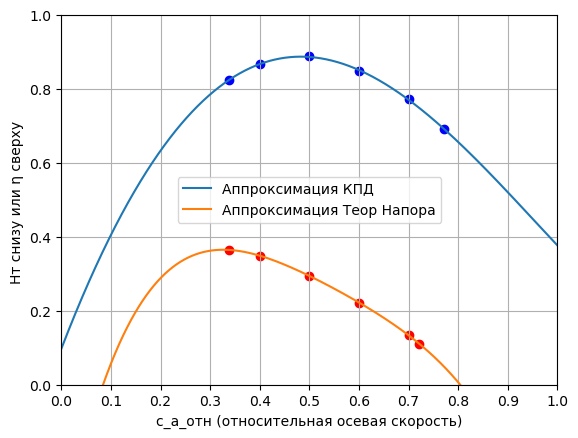

In [663]:
# График с учебника рис. 4

# Точки
x_η_dots = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.770588235294])       # точки по оси X для теоретического напора
η_dots = np.array([0.82371541502, 0.866403, 0.88774703, 0.849604743, 0.771343873, 0.692490118577])      # точки по оси Y для теоретического напора

x_Hт_dots = np.array([0.337091988131, 0.4, 0.5, 0.6,0.7, 0.721379310345])    # точки по оси X для КПД
Hт_dots = np.array([0.36446601942, 0.34854368932, 0.294174757282, 0.221747572816, 0.13360824742, 0.11038026721]) # точки по оси Y для КПД

# аппроксимация полиномом степени stepen
stepen = 4
coeffs = np.polyfit(x_Hт_dots, Hт_dots, stepen)
poly = np.poly1d(coeffs)
coeffs1 = np.polyfit(x_η_dots, η_dots, stepen)
poly1 = np.poly1d(coeffs1)

smoothness = 100000     # Число точек
x_Hт_dots_smooth = np.linspace(0, 1, smoothness)
Hт_dots_smooth = poly(x_Hт_dots_smooth)
x_η_dots_smooth = np.linspace(0, 1, smoothness)
η_dots_smooth = poly1(x_η_dots_smooth)

plt.plot(x_η_dots_smooth, η_dots_smooth, label="Аппроксимация КПД")
plt.plot(x_Hт_dots_smooth, Hт_dots_smooth, label="Аппроксимация Теор Напора")
plt.scatter(x_Hт_dots, Hт_dots, color="red")
plt.scatter(x_η_dots, η_dots, color="blue")
plt.xlim(0,1)
plt.ylim(0,1)
plt.xticks(np.arange(0, 1.1, 0.1))  # Установка делений по оси X с шагом 0.1
plt.yticks(np.arange(0, 1.1, 0.2))  # Установка делений по оси Y с шагом 0.2
plt.xlabel("c_a_отн (относительная осевая скорость)")
plt.ylabel("Hт снизу или η сверху ")
plt.grid(True) # Добавление сетки
plt.legend()
plt.show()

Hт_x_line = x_Hт_dots_smooth    # Координаты X для линии теоретического напора
Hт_y_line = Hт_dots_smooth      # Координаты Y для линии теоретического напора
η_x_line = x_η_dots_smooth      # Координаты X для линии КПД
η_y_line = η_dots_smooth        # Координаты Y для линии КПД


In [664]:
Tа_полн = 288   # K
Pа_полн = 1.013 * 10**5  # Па
G_в = 58.7  # кг/с
π_к_полн = 18.2  # Степень повышения давления в компрессоре
n = 8600  # об/мин

R_в = 287.4  # Дж/(кг*К)
k = 1.4  # показатель адиабаты для воздуха
# Дж/(кг*К) удельная теплоемкость при постоянном давлении для воздуха

In [665]:
n = n / (60 / (2 * math.pi))  # Преобразуем обороты в радианы в секунду
print(f" n = {n}")

 n = 900.589894029074


# 2. Выбор основных параметров компрессора и предварительный расчет проточной части по средней линии тока

## Предварительный расчет проточной части по средней линии тока

In [ ]:
d1_отн = 0.3
c_а1_отн = 0.56
c_a2_отн = 0.36
Hт_ср_отн = 0.4
H_т1 = 0.15
R_ср1 = 0.5
D_type = 'D_к_const'

# Первое приближение

In [667]:
# Ограничения

MAX_UK1 = 350.0            # Верхний предел окружной скорости 1-й ступени, м/с
MAX_CA_DROP = 12.0         # Максимально допустимое падение c_a между соседними ступенями, м/с
MIN_BLADE_HEIGHT = 20e-3   # Минимальная высота лопатки, м
MAX_D3_REL = 0.92          # Максимальный относительный диаметр втулки последней ступени

In [668]:
def η_к_полн_def(π_к_полн, k, η_пол):
    η_к_полн = (((π_к_полн)**((k-1)/k)-1) / ((π_к_полн)**((k-1)/(k*η_пол))-1) - 0.02)
    return(η_к_полн)

def Tk_полн_def(π_к_полн, k, η_пол, Tа_полн):
    η_к_полн = η_к_полн_def(π_к_полн, k, η_пол)
    Tk_полн = Tа_полн * (1 + ((π_к_полн**((k-1)/k)-1) / η_к_полн))
    return(Tk_полн)

def a_кр_def(k, R_в, T):
    a_кр = np.sqrt((2*k/(k+1))*R_в*T)
    return(a_кр)

def ρ_полн_def(P_полн, T_полн, R_в):
    ρ_полн = P_полн / (T_полн * R_в)
    return(ρ_полн)

def U_k_def(G_в, n, c_а1_отн, ρ1_полн, d1_отн):
    U_k = np.cbrt((G_в * n**2)/(np.pi * c_а1_отн * ρ1_полн * (1 - d1_отн**2)))
    return(U_k)

def c_real_def(U_k1, c_а_отн):
    c_real = U_k1 * c_а_отн
    return(c_real)

def λ_def(c_real, a_кр):
    λ = c_real / a_кр
    return(λ)

def ε_gdf(k, λ):
    return (1 - (k-1)/(k+1)*λ**2)**(1/(k-1))

def σ_in_gdf(ξ, k, ε, λ):
    return (1 / (1 + ξ * (k/(k+1)) * ε * λ**2))

def σ_out_gdf(ξ, k, ε, λ):
    return (1 - ξ * (k/(k+1)) * ε * λ**2)

def radius_отн(d_отн):
    return np.sqrt( (1 + d_отн**2) / 2)

def c_u_отн_def(r_ср_отн, R_ср, H_т):
    c_u_отн = r_ср_отн * (1 - R_ср) - (H_т / (2 * r_ср_отн))
    return(c_u_отн)

def q_gdf(k, λ):
    return ((k+1)/2)**(1/(k-1)) * λ * (1 - (k-1)/(k+1)*λ**2)**(1/(k-1))

def F_tube(G_в, R_в, T, β, P, q):
    return (G_в * np.sqrt(R_в * T)) / (β * P * q)

def β_k_def(k):
    β = np.sqrt((2*k)/(k+1)) * (2 / (k+1))**(1/(k-1))
    return(β)

def c_p_def(P_poln_Pa, T1_poln_K):
    """
    Находит c_p:
    P_poln_Pa: Давление на входе в Паскалях (Pa)
    T1_poln_K: Температура на входе в Кельвинах (K)
    """
    # Перевод входного давления из Па в бары для сопоставления с таблицей
    P_poln_bar = P_poln_Pa / 1e5
    
    # Получаем список уникальных давлений из таблицы (они уже в барах)
    available_pressures = df['p_bar'].unique()
    
    # 2. Поиск самого близкого давления в барах
    closest_p = available_pressures[np.abs(available_pressures - P_poln_bar).argmin()]
    
    # Фильтруем данные для выбранной изобары
    data_p = df[df['p_bar'] == closest_p].sort_values('T_K')
    
    # 3. Линейная интерполяция по температуре
    # np.interp(целевая_T, список_T_из_таблицы, список_cp_из_таблицы)
    cp_value = np.interp(T1_poln_K, data_p['T_K'], data_p['c_p'])
    
    return cp_value

def find_nearest(c_a_отн, x_line, y_line):
    x_result = []
    y_result = []

    for i in range(len(c_a_отн)):
        index = np.abs(x_line - c_a_отн[i]).argmin() # Находим индекс ближайшего значения в x_line к c_a_отн[i]
        x_result.append(x_line[index])    # Добавляем найденное значение в результат
        y_result.append(y_line[index])  # Добавляем соответствующее значение y_line в результат
    return np.array(x_result), np.array(y_result)

def plot_results(x, y, label_name, y_name):
    ylim_min = math.floor(min(y)*10)/10-0.1
    ylim_max = math.ceil(max(y)*10)/10+0.1
    plt.plot(x, y, label=label_name)
    plt.scatter(x, y, color="red")
    plt.xlim(1,max(x))
    plt.ylim(ylim_min, ylim_max)
    plt.xticks(np.arange(1, max(x)+1, 1))
    plt.yticks(np.arange(ylim_min, ylim_max, 0.1))
    plt.xlabel("n - ступеней")
    plt.ylabel(y_name)
    plt.grid(True) # Добавление сетки
    plt.legend()
    plt.show()

# Предзагрузка таблицы c_p один раз (вместо чтения CSV в каждой итерации model)
def _load_cp_table(csv_path='resources/air_param.csv'):
    data = np.genfromtxt(csv_path, delimiter=',', names=True, dtype=float, encoding='utf-8')
    p_grid = np.unique(data['p_bar'])
    t_grid = np.unique(data['T_K'])
    cp_grid = np.empty((p_grid.size, t_grid.size), dtype=np.float64)

    for ip, p_val in enumerate(p_grid):
        mask = data['p_bar'] == p_val
        t_row = data['T_K'][mask]
        cp_row = data['c_p'][mask]
        order = np.argsort(t_row)
        cp_grid[ip, :] = np.interp(t_grid, t_row[order], cp_row[order])

    return p_grid.astype(np.float64), t_grid.astype(np.float64), cp_grid.astype(np.float64)


P_GRID_BAR, T_GRID_K, CP_GRID = _load_cp_table()

def cp_lookup_array(p_pa_arr, t_k_arr):
    out = np.empty_like(t_k_arr, dtype=np.float64)
    for i in range(t_k_arr.shape[0]):
        p_bar = p_pa_arr[i] / 1e5
        best_idx = int(np.abs(P_GRID_BAR - p_bar).argmin())
        out[i] = np.interp(t_k_arr[i], T_GRID_K, CP_GRID[best_idx]) * 1000.0
    return out

In [669]:
# 1. Импорт и очистка данных
# skipinitialspace=True убирает пробелы после запятых в CSV
df = pd.read_csv('resources/air_param.csv', skipinitialspace=True)

# Очищаем названия колонок от случайных пробелов
df.columns = df.columns.str.strip()

# Принудительно переводим важные колонки в числа. 
# Ошибки (буквы) станут NaN, которые мы потом удалим.
cols_to_fix = ['p_bar', 'T_K', 'c_p']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=cols_to_fix)

In [670]:
# Определим адиабатический КПД
η_пол = 0.90 # Политропический КПД компрессора из рис.1

# Коэффициент потерь полного давления во входном и выходном патрубках
ξ_вх = 0.05     # Для входного патрубка
ξ_вых = 0.15    # Для выходного патрубка

#  Ожидаемый КПД
η_к_полн = η_к_полн_def(π_к_полн, k, η_пол)
π_к_полн_0 = π_к_полн
η_к_полн_0 = η_к_полн

# Температура на выходе из ЛА компрессора
Tk_полн = Tk_полн_def(π_к_полн, k, η_пол, Tа_полн)
T2_полн = Tk_полн

# Критическая скорость звука во входном и выходном патрубках
a_кр_вх = a_кр_def(k, R_в, Tа_полн)
a_кр_вых = a_кр_def(k, R_в, Tk_полн)

# Плотность рабочего тела по заторможенным параметрам
ρ1_полн = ρ_полн_def(Pа_полн, Tа_полн, R_в)

# Окружная скорость реальная на конце лопатки
U_k1 = U_k_def(G_в, n, c_а1_отн, ρ1_полн, d1_отн)
if U_k1 > MAX_UK1:
        print(f"U_k1 > максимально допустимой скорости")

# Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
c_вх = c_real_def(U_k1, c_а1_отн)
c_вых = c_real_def(U_k1, c_a2_отн)

# Приведенные скорости в данных сечениях
λ_вх = λ_def(c_вх, a_кр_вх)
λ_вых = λ_def(c_вых, a_кр_вых)

# ГДФ плотности для входного и выходного патрубков
ε_вх = ε_gdf(k, λ_вх)
ε_вых = ε_gdf(k, λ_вых)

# Коэффициенты сохранения полного давления во входном и выходном патрубках
σ_вх = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
σ_вых = σ_out_gdf(ξ_вых, k, ε_вых, λ_вых)


π_ла_полн = π_к_полн / (σ_вх * σ_вых)
η_ла_полн = ((π_ла_полн)**((k-1)/k)-1) / ((π_ла_полн)**((k-1)/(k*η_пол))-1)

π_ла_полн_0 = π_ла_полн
η_ла_полн_0 = η_ла_полн

print(f"""
σ_вх * σ_вых = {σ_вх * σ_вых}
π_ла_полн = {π_ла_полн}
η_к_полн = {η_к_полн}
η_ла_полн = {η_ла_полн}
""")


σ_вх * σ_вых = 0.9892065047112885
π_ла_полн = 18.398585040958544
η_к_полн = 0.8338097173818555
η_ла_полн = 0.8536207597814136



In [671]:
U_k1_before = U_k1 * 100
number = 1
while True:
    # Осевая скорость на переферии РК
    c_а1 = c_real_def(U_k1, c_а1_отн)
    
    # Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
    c_вх = c_real_def(U_k1, c_а1_отн)
    c_вых = c_real_def(U_k1, c_a2_отн)

    # Пренебрегая теплообменом в трубках:
    T1_полн = Tа_полн


    # Температура на выходе из ЛА компрессора
    Tk_полн = Tk_полн_def(π_к_полн, k, η_пол, Tа_полн)
    T2_полн = Tk_полн

    # Критическая скорость звука во входном и выходном патрубках
    a_кр_вх = a_кр_def(k, R_в, Tа_полн)
    a_кр_вых = a_кр_def(k, R_в, Tk_полн)

    # Приведенные скорости в данных сечениях
    λ_вх = λ_def(c_вх, a_кр_вх)
    λ_вых = λ_def(c_вых, a_кр_вых)

    # Коэффициент потерь полного давления во входном и выходном патрубках
    ξ_вх = 0.05     # Для входного патрубка
    ξ_вых = 0.15    # Для выходного патрубка

    # ГДФ плотности для входного и выходного патрубков
    ε_вх = ε_gdf(k, λ_вх)       
    ε_вых = ε_gdf(k, λ_вых)
    #  !!!!!!!!Перепроверить верность выражений в функции!

    # Коэффициенты сохранения полного давления во входном и выходном патрубках
    σ_вх = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
    σ_вых = σ_out_gdf(ξ_вых, k, ε_вых, λ_вых)

    # Полные давления на входе и выходе из лопаточного аппарата
    P1_полн = σ_вх * Pа_полн
    Pк_полн = Pа_полн * π_к_полн
    P2_полн = Pк_полн / σ_вых
    # Средний радиус на входе в первую степень
    r_ср1_отн = radius_отн(d1_отн)

    # Безразмерная окружная составляющая абсолютной скорости на входе
    c_1u_отн = c_u_отн_def(r_ср1_отн, R_ср1, H_т1)

    # Абсолютная скорость: 
    c1 = U_k1 * math.sqrt(c_а1_отн**2 + c_1u_отн**2)

    # Приведенная скорость:
    λ1 = λ_def(c1, a_кр_вх)

    # ГДФ плотности
    ε = (1 - ((k-1)/(k+1)) * λ1**2)**(1/(k-1))
    # !!!!!!!!Перепроверить верность выражения!!!!!!!

    # Плотность рабочего тела перед РК
    ρ1 = ρ_полн_def(P1_полн, T1_полн, R_в) * ε
    # !!!!!!!!Перепроверить верность выражения!!!!!!!

    # Перерасчет окружной скорости конца рабочей лопатки
    U_k1 = U_k_def(G_в, n, c_а1_отн, ρ1, d1_отн)
    loss_percenteg = 0.00001
    # Цикл, который проверяет разницу между предыдущим и нынешним числом. Нужен для проведения итераций
    if abs((U_k1 - U_k1_before)/U_k1)*100 <= loss_percenteg:
        break
    else:
        U_k1_before = U_k1  # Запись предыдущего числа для последующего сравнения в дальнейшем
        number = number + 1 # Подсчет числа итераций
    

In [672]:
# Значение абсолютной скорости на выходе из входного патрубка и на входе в выходной патрубок
c_вх = c_real_def(U_k1, c_а1_отн)
c_вых = c_real_def(U_k1, c_a2_отн)

# Приведенные скорости в данных сечениях
λ_вх = λ_def(c_вх, a_кр_вх)
λ_вых = λ_def(c_вых, a_кр_вых)

# Коэффициент потерь полного давления во входном и выходном патрубках
ξ_вх = 0.05     # Для входного патрубка
ξ_вых = 0.15    # Для выходного патрубка

# ГДФ плотности для входного и выходного патрубков
ε_вх = ε_gdf(k, λ_вх)
ε_вых = ε_gdf(k, λ_вых)

# Коэффициенты сохранения полного давления во входном и выходном патрубках
σ_вх = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
σ_вых = σ_out_gdf(ξ_вых, k, ε_вых, λ_вых)

# Полные давления на входе и выходе из лопаточного аппарата
P1_полн = σ_вх * Pа_полн
P2_полн = Pа_полн * π_к_полн / σ_вых

# Степень повышения полного давления лопаточного аппарата
π_ла_полн = P2_полн / P1_полн
π_к_полн = π_ла_полн * (σ_вых * σ_вх)

# КПД лопаточного аппарата
η_ла = σ_вых * σ_вх  # Должно быть 1

# Коэффициент C определяется из графика на рис. 7
C = 0.98  # Надо написать функцию для определения C по графику, а не брать константное значение
# !!!!!!!!
# !!!!!!!!

η_ла_полн = η_к_полн / C
η_к_полн = η_ла_полн * ((π_к_полн**((k-1)/k)-1)/(π_ла_полн**((k-1)/k)-1))


β = β_k_def(k)

# Приведенная плотность потока массы
q_вх = q_gdf(k, λ_вх)
q_вых = q_gdf(k, λ_вых)
# Кольцевые площади на выходе из входного патрубка и на входе в выходной патрубок
F_вх = F_tube(G_в, R_в, T1_полн, β, P1_полн, q_вх)
F_вых = F_tube(G_в, R_в, T2_полн, β, P2_полн, q_вых)

In [673]:
# Наружный диаметр ротора:
D_к1 = 2 * U_k1 / n

# Внутренний диаметр
D_вт1 = D_к1 * d1_отн

# Средний диаметр
D_ср1 = D_к1 * r_ср1_отн

# Высота лопатки РК 1-й ступени:
h_1 = (1/2) * D_к1 * (1 - d1_отн)

In [674]:
# Выбор формы проточной части лопаточного аппарата. 

if D_type == 'D_к_const':
    # Dк = const

    D_к = D_к1
    
    # Диаметр втулки лопаток последнйей ступени:
    D_вт_n = math.sqrt(D_к**2 - ((4 * F_вых) / math.pi))
    # Относительный диаметр втулки рабочего колеса последней ступени:
    d_n_отн = D_вт_n / D_к
    h_n = (1/2) * D_к * (1 - d_n_отн)

elif D_type == 'D_вт_const':
    # Dвт = const

    D_вт = D_вт1
    D_к_n = math.sqrt(D_вт**2 + (4 * F_вых / math.pi))
    d_n_отн = D_вт / D_к_n
    h_n = (1/2) * (D_к_n - D_вт)


else:
    # Dср = const
    
    D_ср = D_ср1
    D_к_n = math.sqrt(D_ср**2 + (2 * F_вых / math.pi))
    D_вт_n = math.sqrt(D_ср**2 - ((2 * F_вых) / math.pi))
    h_n = (1/2)*(D_к_n - D_вт_n)
    d_n_отн = d1_отн

In [675]:
# Окружная скорость концов рабочих лопаток "средней" ступени:
ρ2 = ρ_полн_def(P2_полн, T2_полн, R_в)
U_k1 = U_k_def(G_в, n, c_а1_отн, ρ1, d1_отн)
U_k2 = U_k_def(G_в, n, c_a2_отн, ρ2, d_n_отн)
U_к_ср = (U_k1 + U_k2) / 2
# Теоретический напор "средней" ступени:
Hт_ср = Hт_ср_отн * (U_к_ср**2)

# Адиабатический напор компрессора по параметрам затарможенного потока
H_ад_к_полн = (k*R_в)/(k-1) * Tа_полн*((π_к_полн ** ((k-1)/k))-1)

# Сумма теоретических напоров по ступеням:
H_тк = H_ад_к_полн / η_к_полн

# Число ступеней компрессора:
z = H_тк / Hт_ср
z = math.ceil(z)
N_stupeney = z

if D_type == 'D_к_const':
    D_к_i = np.linspace(D_к, D_к, N_stupeney)
elif D_type == 'D_вт_const':
    D_к_i = np.linspace(D_к, D_к_n, N_stupeney)
else:
    D_к_i = np.linspace(D_к, D_к_n, N_stupeney)

In [676]:
N = z   # Число ступеней компрессора
N_list = np.linspace(1, N, N)   # Массив от 1 до N для итерации по ступеням

Hт_x_i_отн = []
Hт_i_отн = []

c_a_i_отн = np.linspace(c_а1_отн, c_a2_отн, N) # Линейно изменяющийся коэффициент расхода от первой до последней ступени

In [677]:
Hт_x_i_отн, Hт_i_отн = find_nearest(c_a_i_отн, Hт_x_line, Hт_y_line)
η_x_i_отн, η_ад_полн_i = find_nearest(c_a_i_отн, η_x_line, η_y_line)

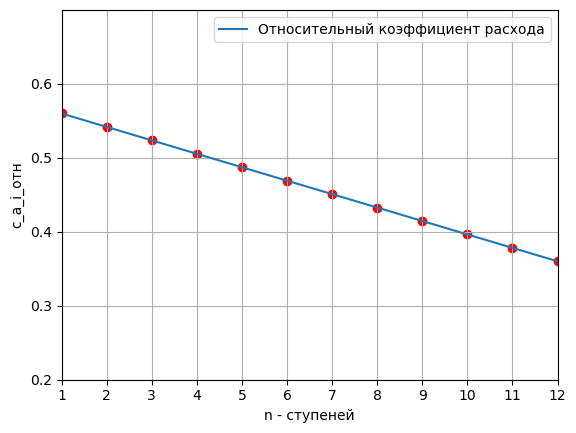

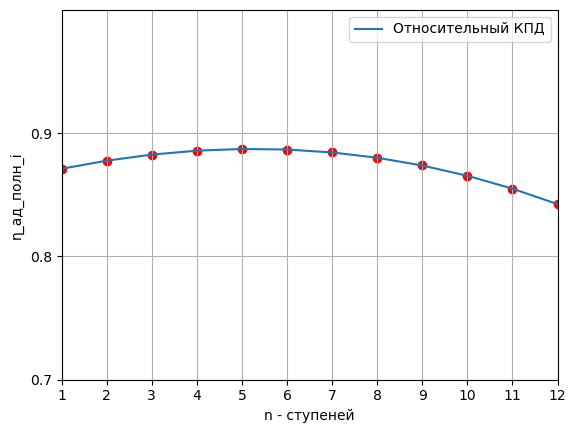

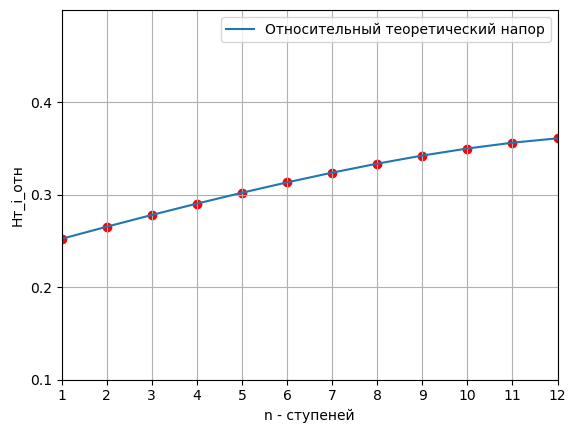

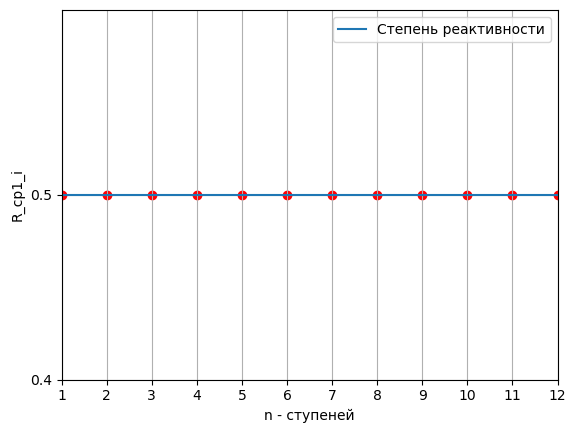

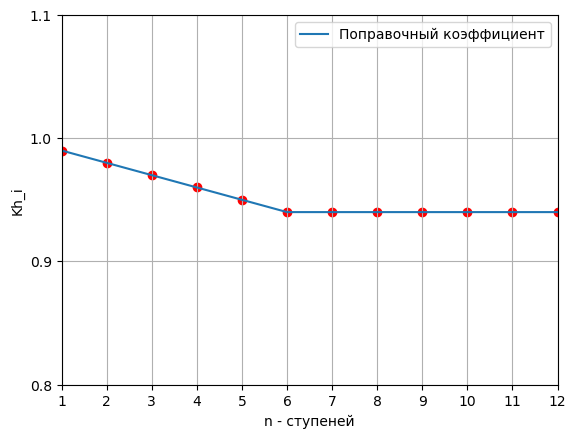

In [678]:
R_ср1_list = np.linspace(R_ср1, R_ср1, N)  # Создаем массив из N элементов, все равные R_ср1
Kh_i = np.concatenate([
    np.linspace(0.99, 0.94, 6),
    np.full((N-6), 0.94)
])

plot_results(N_list, c_a_i_отн, "Относительный коэффициент расхода", "c_a_i_отн")
plot_results(N_list, η_ад_полн_i, "Относительный КПД", "η_ад_полн_i")
plot_results(N_list, Hт_i_отн, "Относительный теоретический напор", "Hт_i_отн")
plot_results(N_list, R_ср1_list, "Степень реактивности", "R_ср1_i")
plot_results(N_list, Kh_i, "Поправочный коэффициент", "Kh_i")

In [679]:
# Расчет ВНА
# Коэффициент сохранения полного давления в ВНА
# Направление абсолютной скорости на входе в ВНА
σ_вх_вна = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
P1_полн_вна = σ_вх_вна * Pа_полн
c_1u_вна = c_u_отн_def(radius_отн(d1_отн), R_ср1, H_т1)
α_1_вна = math.radians(90)
α_2_вна = (math.atan(c_а1_отн / c_1u_отн))


In [680]:
(c_a_i_отн[-1] - (c_a_i_отн[-2] - c_a_i_отн[-1]))

np.float64(0.3418181818181818)

In [681]:
c_a_i_отн

array([0.56      , 0.54181818, 0.52363636, 0.50545455, 0.48727273,
       0.46909091, 0.45090909, 0.43272727, 0.41454545, 0.39636364,
       0.37818182, 0.36      ])

# 3. Поступенчатый расчет значений для каждой ступени

In [682]:
# Коэффициент расхода на выходе из ступени
# c_a_i_отн_plus_1 = np.concatenate((c_a_i_отн[1:], [c_a_i_отн[-1]])) Убрать потом формулу ниже и вернуть эту
c_a_i_отн_plus_1 = np.concatenate((c_a_i_отн[1:], [(c_a_i_отн[-1] - (c_a_i_отн[-2] - c_a_i_отн[-1]))]))
# Давление перед ступенями по длине компрессора
P1_полн_i = np.linspace(P1_полн, P2_полн, N)

# Температура перед ступенью по длине компрессора
T1_полн_i = np.linspace(T1_полн, T2_полн, N)

# Диаметры относительные по длине компрессора
d1_отн_i = np.linspace(d1_отн, d_n_отн, N)

# Окружные скорости по длине компрессора
U_k_i = np.linspace(U_k1, U_k2, N)

# Проверка: c_a не должна падать более чем на MAX_CA_DROP м/с между соседними ступенями
c_a_i_real = c_a_i_отн * U_k_i
if np.max(c_a_i_real[:-1] - c_a_i_real[1:]) > MAX_CA_DROP:
    print(f"Изменение скорости в ступени больше 12м/с")

# Начало расчета из Бекнева
# 1. Теоретический напор для i-й ступени:
Hт_i = Hт_i_отн * (U_k_i**2)

# 2. Действительная работа сжатия для i-й ступени:
L_z_i = Kh_i * Hт_i

# 3. Адиабатическая работа сжатия для i-й ступени:
H_ад_i = L_z_i * η_ад_полн_i

# Генерация c_p для каждой ступени через предзагруженную таблицу (Numba/Python fallback)
c_p_i = cp_lookup_array(P1_полн_i, T1_полн_i)
    
# 4. Повышение полной температуры в ступени:
ΔT_полн_i = L_z_i / c_p_i # с_р в каждой ступени разный т.к. меняется температура

# 5. Полная температура на выходе из ступени:
T3_полн_i = T1_полн_i + ΔT_полн_i
T1_полн_i_plus_1 = T3_полн_i    # Температура на выходе становится температурой на входе в следующую ступень

# 6. Степень повышения полного давления:
π_полн_i = (1 + (H_ад_i / (c_p_i * T1_полн_i)))**(k/(k-1))
   
# 7. Полное давление на выходе из ступени:
P3_полн_i = P1_полн_i * π_полн_i 
P1_полн_i_plus_1 = P3_полн_i
    
# 8. Критическая скорость потока на входе и выходе:
a_кр_1_i = np.sqrt((2*k/(k+1))*R_в*T1_полн_i)
a_кр_3_i = np.sqrt((2*k/(k+1))*R_в*T3_полн_i)
    
# 9. Средний радиус на входе в i-ю ступень:
r_ср1_отн_i = np.sqrt( (1 + d1_отн_i**2) / 2)
    
# 10. Безразмерная окружная составляющая абсолютной скорости на входе в i-ю ступень:
c_u1_отн_i = r_ср1_отн_i * (1 - R_ср1) - (Hт_i_отн / (2 * r_ср1_отн_i))
    
# 11. Направление абсолютной скорости на входе
α_1_i = np.arctan(c_a_i_отн / c_u1_отн_i)
    
# 12. Приведенная скорость на входе
c_a1_i = c_a_i_отн * U_k_i
λ_1_i = c_a1_i / (np.sin(α_1_i) * a_кр_1_i)
    
# 13. ГДФ расхода
q_1_i = q_gdf(k, λ_1_i)

# 14. Кольцевая площадь на входе в ступень
F_1_i = (G_в * np.sqrt(R_в * T1_полн_i)) / (β * P1_полн_i * q_1_i * np.sin(α_1_i))

# 15. Кольцевая площадь на выходе из ступени F3
c_a3_отн_i = c_a_i_отн_plus_1
c_a3_i = c_a3_отн_i * U_k_i
λ_3_i_0 = c_a3_i / (np.sin(α_1_i) * a_кр_3_i)

q_3_i = q_gdf(k, λ_3_i_0)
F_3_i_0 = F_1_i * ((q_1_i * P1_полн_i) / (q_3_i * P3_полн_i)) * np.sqrt(T3_полн_i / T1_полн_i)
    
# 16. Относительный диаметр втулки на выходе из ступени d3отн в первом прибляж для принятой ф. проточной части Dk = const
if D_type == 'D_к_const':
    # Dк = const

    D_к = D_к1
    # Диаметр втулки лопаток последнйей ступени:
    D_вт3_i_0 = np.sqrt(D_к**2 - ((4 * F_3_i_0) / np.pi))
    # Относительный диаметр втулки рабочего колеса последней ступени:
    d3_отн_i_0 = D_вт3_i_0 / D_к

elif D_type == 'D_вт_const':
    # Dвт = const

    D_вт = D_вт1
    D_к3_i_0 = np.sqrt(D_вт**2 + ((4 * F_3_i_0)/ np.pi))
    d3_отн_i_0 = D_вт / D_к3_i_0

else:
    # Dср = const

    D_ср = D_ср1
    D_к_n = np.sqrt(D_ср**2 + (2 * F_3_i_0 / math.pi))
    D_вт_n = np.sqrt(D_ср**2 - ((2 * F_3_i_0) / math.pi))
    d3_отн_i_0 = np.linspace(d1_отн, d1_отн, N)
    
# Относительный средний радиус на выходе из ступени
r_ср3_отн_i = np.sqrt( (1 + d3_отн_i_0**2) / 2)

# 17. Безразмерная окружная состовляющая абсолютной скорости на выходе
R_ср1_i_plus_1 = np.concatenate((R_ср1_list[1:], [R_ср1_list[-1]]))
# Hт_i_отн_plus_1 = np.concatenate((Hт_i_отн[1:], [Hт_i_отн[-1]])) # Убрать потом формулу ниже и вернуть эту
Hт_i_отн_plus_1 = np.concatenate((Hт_i_отн[1:], [(Hт_i_отн[-1] - (Hт_i_отн[-2] - Hт_i_отн[-1]))]))

c_3u_отн_i = r_ср3_отн_i * (1 - R_ср1_i_plus_1) - (Hт_i_отн / (2 * r_ср3_отн_i))

# 18. Направление потока в абсолютном движении после НА
α_3_i = np.atan(c_a3_отн_i / c_3u_отн_i)

# 19. Приведенная скорость на выходе
λ_3_i = c_a3_i / (np.sin(α_3_i) * a_кр_3_i)

# 20. Действительная кольцевая площадь на выходе из ступени
F_3_i = F_3_i_0 * ((q_gdf(k, λ_3_i_0)) / (q_gdf(k, λ_3_i)))
# F_1_i_plus_1 = np.concatenate((F_3_i[1:], [F_3_i[-1]])) Убрать потом формулу ниже и вернуть эту
F_1_i_plus_1 = np.concatenate((F_3_i[1:], [(F_3_i[-1] - (F_3_i[-2] - F_3_i[-1]))]))

# 21. Действительный относительный диаметр втулки d_3_отн подсчитывется в завис от типа проточн части.
if D_type == 'D_к_const':
    D_вт3_i = np.sqrt(D_к**2 - ((4 * F_3_i) / np.pi))
    d3_отн_i = D_вт3_i / D_к1
        
    # Ограничение на высоту лопатки
    h_lopatki = D_к - D_вт3_i[-1]
    if (h_lopatki < MIN_BLADE_HEIGHT) or (d3_отн_i[-1] > MAX_D3_REL):
        print(f"Непопадение в условия")

elif D_type == 'D_вт_const':
    D_к3_i = np.sqrt(D_вт1**2 + ((4 * F_3_i)/ np.pi))
    d3_отн_i = D_вт / D_к3_i
    D_вт = D_вт1

    # Ограничение на высоту лопатки
    h_lopatki = D_к3_i[-1] - D_вт
    if (h_lopatki < MIN_BLADE_HEIGHT) or (d3_отн_i[-1] > MAX_D3_REL):
        print(f"Непопадение в условия")
else:
    d3_отн_i = np.linspace(d1_отн, d1_отн, N)
    D_ср = D_ср1
    D_к_n = np.sqrt(D_ср**2 + (2 * F_3_i / math.pi))
    D_вт_n = np.sqrt(D_ср**2 - ((2 * F_3_i) / math.pi))

    # Ограничение на высоту лопатки
    h_lopatki = D_к_n[-1] - D_вт_n[-1]
    if (h_lopatki < MIN_BLADE_HEIGHT) or (d3_отн_i[-1] > MAX_D3_REL):
        print(f"Непопадение в условия")    

# 22. Средний радиус на выходе из ступени
r_ср3_отн_i = np.sqrt( (1 + d3_отн_i**2) / 2)

# 23. Средний радиус на выходе из рабочего колеса
r_ср2_отн_i = (r_ср1_отн_i + r_ср3_отн_i) / 2

# 24. Безразмерная окружная составляющая абсолютной скорости на выходе из рабочего колеса
c_u2_отн_i = (1 / r_ср2_отн_i) * (Hт_i_отн + c_u1_отн_i * r_ср1_отн_i)

# 25. Углы потока в относительном движении
β_1_i = np.atan((c_a_i_отн / (r_ср1_отн_i- c_u1_отн_i)))
c_a2_отн_i = (c_a_i_отн + c_a_i_отн_plus_1) / 2
β_2_i = np.atan((c_a2_отн_i / (r_ср2_отн_i- c_u2_отн_i)))
    
# 26. Направление потока в абсолютном движении после рабочего колеса
α_2_i = np.atan(c_a2_отн_i / c_u2_отн_i)
    
# 27. Углы поворота потока в средних сечениях лопаток РК и НА
ε_рк_i = β_2_i - β_1_i
ε_на_i = α_3_i - α_2_i

# 28. Относительная скорость на среднем радиусе на входе в РК
W_1_i = c_a1_i / np.sin(β_1_i)

# 29. Абсолютная скорость на среднем радиусе на входе в НА
c_a2_i = c_a2_отн_i * U_k_i
c_2_i = c_a2_i / np.sin(α_2_i)

# 30. Число Маха по относительной скорости на входе в РК
# ГДФ температуры на входе в РК
τ_1_i = (1 - (λ_1_i**2)*((k-1)/(k+1)))
# Статическая температура перед РК
T_1_i = T1_полн_i * τ_1_i
# Скорость звука на входе в РК
a_1_i = a_кр_def(k, R_в, T_1_i)

M_w1_i = W_1_i / a_1_i

# 31. Число Маха по абсолютной скорости на входе в НА
# Приведенная скорость перед НА
λ_c2_i = c_2_i / a_кр_3_i
# Статическая температура перед НА
T2_полн_i = T3_полн_i
τ_2_i = (1 - (λ_c2_i**2)*((k-1)/(k+1)))
T_2_i = T2_полн * τ_2_i
# Скорость звука на входе в НА
a_2_i = a_кр_def(k, R_в, T_2_i)

M_c2_ср_i = c_2_i / a_2_i



# Надо перепроверить, нужно ли все, что ниже!!!!!!!!!!
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# Абсолютная скорость на входе в РК
c_1_i = U_k_i * np.sqrt(c_a_i_отн**2 + c_u1_отн_i**2)
# Плотность заторможенного потока на выходе из ступени
ε_3_i = (1 - (k-1)/(k+1)*λ_3_i**2)**(1/(k-1))
ρ3_i = ((P3_полн_i) / (R_в * T3_полн_i)) * ε_3_i
# Относительная скорость на среднем радиусе на входе в НА
W_2_i = c_a2_i / np.sin(β_2_i)

    
# Высота лопаток рабочего колеса
D_вт1_i = D_к * d1_отн_i
h_рк_i = 0.5 * (D_к - D_вт1_i)
    
# Относительный диаметр втулки на выходе из РК
d2_отн_i = np.sqrt(2 * (r_ср2_отн_i**2) - 1)
D_ср_1 = D_к * r_ср1_отн_i
D_ср_2 = D_к * r_ср2_отн_i
D_ср_3 = D_к * r_ср3_отн_i
    
# Периферийный диаметр на выходе из РК
D_вт2_i = D_к * d2_отн_i
D_вт1_i = D_к * d1_отн_i
    
# Высота лопаток НА
h_на_i = 0.5 * (D_к - D_вт2_i)
h_на_3_i = 0.5 * (D_к - D_вт3_i)

In [683]:
F_1_i

array([0.32669624, 0.14532796, 0.10274705, 0.08435414, 0.0745371 ,
       0.0687832 , 0.06531106, 0.06328239, 0.06225706, 0.06198837,
       0.06233424, 0.06321493])

In [684]:
π_ла_полн = P2_полн / P1_полн
η_ла_полн = (T1_полн * (π_ла_полн**((k-1)/k) - 1)) / (T2_полн - T1_полн)

# Коэффициенты сохранения полного давления во входном и выходном патрубках
σ_вх = σ_in_gdf(ξ_вх, k, ε_вх, λ_вх)
σ_вых = σ_out_gdf(ξ_вых, k, ε_вых, λ_вых)

π_к_полн = π_ла_полн * σ_вх * σ_вых

# Есть два варианта расчета кпд из учебника, будто 2 вариант круче
# !!!!!!!!!!!!!!!!!!!!!!!!!!
Tk_полн_new = T2_полн
T1_полн_new = Tа_полн

η_к_полн = np.sum(H_ад_i) / np.sum(L_z_i) - 0.02
N_к = G_в * np.sum(L_z_i)
print(f"""
π_ла_полн = {π_ла_полн}
η_ла_полн = {η_ла_полн}

π_ла_полн_0 = {π_ла_полн_0}
η_ла_полн_0 = {η_ла_полн_0}

π_к_полн = {π_к_полн:.4f}
η_к_полн = {η_к_полн:.4f}

π_к_полн_0 = {π_к_полн_0:.4f}
η_к_полн_0 = {η_к_полн_0:.4f}

N_к = {N_к}

N_stupeney = {N_stupeney}
""")


π_ла_полн = 18.41956872653582
η_ла_полн = 0.8388882479403943

π_ла_полн_0 = 18.398585040958544
η_ла_полн_0 = 0.8536207597814136

π_к_полн = 18.2000
η_к_полн = 0.8536

π_к_полн_0 = 18.2000
η_к_полн_0 = 0.8338

N_к = 19552145.070075635

N_stupeney = 12



In [685]:
import os
import numpy as np
import pandas as pd

# Список всех имён переменных-списков
list_names = [
    "c_a_i_отн","c_a_i_отн_plus_1","P1_полн_i",
    "T1_полн_i","d1_отн_i","U_k_i","Hт_i","L_z_i","H_ад_i",
    "ΔT_полн_i","T3_полн_i","T1_полн_i_plus_1","π_полн_i",
    "P3_полн_i","P1_полн_i_plus_1","a_кр_1_i","a_кр_3_i",
    "r_ср1_отн_i","c_u1_отн_i","α_1_i","c_a1_i","λ_1_i",
    "q_1_i","F_1_i","c_a3_отн_i","c_a3_i","λ_3_i_0","q_3_i",
    "F_3_i_0","d3_отн_i_0","r_ср3_отн_i","c_3u_отн_i","α_3_i",
    "λ_3_i","F_3_i","F_1_i_plus_1","d3_отн_i","r_ср2_отн_i",
    "c_u2_отн_i","β_1_i","c_a2_отн_i","β_2_i","α_2_i","ε_рк_i",
    "ε_на_i","W_1_i","c_a2_i","c_2_i","τ_1_i","T_1_i","a_1_i",
    "M_w1_i","λ_c2_i","T2_полн_i","τ_2_i","T_2_i","a_2_i","M_c2_ср_i"
]

# ──────────────────────────────────────────────────────
# СБОР ДАННЫХ
# ──────────────────────────────────────────────────────

data = {}

for name in list_names:
    val = globals().get(name, [])

    # нормализация типов
    if isinstance(val, np.ndarray):
        val = val.tolist()
    elif not isinstance(val, (list, tuple)):
        val = [val]

    data[name] = list(val)


# ──────────────────────────────────────────────────────
# ВЫРАВНИВАНИЕ ДЛИН (важно!)
# ──────────────────────────────────────────────────────

if data:
    max_len = max(len(col) for col in data.values())

    for key, col in data.items():
        if len(col) < max_len:
            data[key] = col + [np.nan] * (max_len - len(col))

    df = pd.DataFrame(data)
else:
    df = pd.DataFrame({"info": ["Нет данных"]})


# ──────────────────────────────────────────────────────
# НАСТРОЙКА ВЫВОДА
# ──────────────────────────────────────────────────────

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x: .4g}')

display(df)


# ──────────────────────────────────────────────────────
# СОХРАНЕНИЕ В results
# ──────────────────────────────────────────────────────

output_dir = "results"
os.makedirs(output_dir, exist_ok=True)

file_path = os.path.join(output_dir, "поступенчатый_расчет_ступеней.xlsx")

df.to_excel(file_path, index=False)

# опционально CSV
# df.to_csv(os.path.join(output_dir, "расчет_ступеней.csv"), index=False)

print(f"✅ Сохранено: {file_path}")

,c_a_i_отн,c_a_i_отн_plus_1,P1_полн_i,T1_полн_i,d1_отн_i,U_k_i,Hт_i,L_z_i,H_ад_i,ΔT_полн_i,T3_полн_i,T1_полн_i_plus_1,π_полн_i,P3_полн_i,P1_полн_i_plus_1,a_кр_1_i,a_кр_3_i,r_ср1_отн_i,c_u1_отн_i,α_1_i,c_a1_i,λ_1_i,q_1_i,F_1_i,c_a3_отн_i,c_a3_i,λ_3_i_0,q_3_i,F_3_i_0,d3_отн_i_0,r_ср3_отн_i,c_3u_отн_i,α_3_i,λ_3_i,F_3_i,F_1_i_plus_1,d3_отн_i,r_ср2_отн_i,c_u2_отн_i,β_1_i,c_a2_отн_i,β_2_i,α_2_i,ε_рк_i,ε_на_i,W_1_i,c_a2_i,c_2_i,τ_1_i,T_1_i,a_1_i,M_w1_i,λ_c2_i,T2_полн_i,τ_2_i,T_2_i,a_2_i,M_c2_ср_i
0,0.56,0.5418,1.005e+05,288,0.3,306,2.362e+04,2.338e+04,2.037e+04,23.25,311.2,311.2,1.268,1.275e+05,1.275e+05,310.8,323,0.7382,0.1982,1.231,171.3,0.5849,0.7967,0.3267,0.5418,165.8,0.5444,0.7566,0.2819,0.4717,0.7861,0.2296,1.17,0.5574,0.2771,0.1196,0.4856,0.7622,0.523,0.8036,0.5509,1.161,0.8113,0.3577,0.3587,238,168.6,232.4,0.943,271.6,301.8,0.7888,0.7195,311.2,0.9137,670.6,474.2,0.4902
1,0.5418,0.5236,2.597e+05,328.5,0.3555,305.8,2.482e+04,2.432e+04,2.135e+04,24.08,352.6,352.6,1.244,3.23e+05,3.23e+05,331.9,343.9,0.7505,0.1984,1.22,165.7,0.5316,0.7433,0.1453,0.5236,160.1,0.4959,0.7046,0.1277,0.8049,0.9138,0.3077,1.04,0.5401,0.1196,0.08467,0.8186,0.8321,0.4979,0.776,0.5327,1.01,0.8192,0.2344,0.2204,236.5,162.9,223,0.9529,313.1,324,0.7301,0.6485,352.6,0.9299,682.5,478.4,0.4661
2,0.5236,0.5055,4.189e+05,369.1,0.411,305.6,2.598e+04,2.52e+04,2.224e+04,24.79,393.9,393.9,1.223,5.124e+05,5.124e+05,351.8,363.4,0.7645,0.2003,1.205,160,0.4871,0.6946,0.1027,0.5055,154.5,0.4551,0.6575,0.09165,0.8644,0.9398,0.3186,1.008,0.5024,0.08467,0.06992,0.8755,0.8522,0.5061,0.7482,0.5145,0.9788,0.7937,0.2306,0.2148,235.2,157.2,220.6,0.9605,354.5,344.8,0.6823,0.6069,393.9,0.9386,688.8,480.6,0.4589
3,0.5055,0.4873,5.781e+05,409.6,0.4665,305.4,2.709e+04,2.6e+04,2.303e+04,25.52,435.1,435.1,1.207,6.976e+05,6.976e+05,370.6,382,0.7803,0.204,1.187,154.4,0.4492,0.6505,0.08435,0.4873,148.8,0.4202,0.6151,0.07619,0.8888,0.9506,0.3195,0.9904,0.4659,0.06992,0.06233,0.8984,0.8654,0.5195,0.7201,0.4964,0.9622,0.7626,0.2421,0.2278,234.1,151.6,219.4,0.9664,395.8,364.3,0.6426,0.5745,435.1,0.945,693.5,482.2,0.4551
4,0.4873,0.4691,7.372e+05,450.1,0.522,305.2,2.815e+04,2.674e+04,2.373e+04,26.09,476.2,476.2,1.192,8.787e+05,8.787e+05,388.5,399.6,0.7977,0.2094,1.165,148.7,0.4167,0.6107,0.07454,0.4691,143.2,0.39,0.5769,0.0681,0.9012,0.9561,0.3172,0.9762,0.4325,0.06233,0.05815,0.91,0.8769,0.5351,0.6918,0.4782,0.9503,0.7293,0.2585,0.2469,233.1,145.9,219,0.9711,437.1,382.8,0.609,0.5481,476.2,0.9499,697.2,483.5,0.453
5,0.4691,0.4509,8.964e+05,490.7,0.5775,305,2.916e+04,2.741e+04,2.43e+04,26.57,517.3,517.3,1.178,1.056e+06,1.056e+06,405.6,416.5,0.8166,0.2164,1.139,143.1,0.3885,0.575,0.06878,0.4509,137.5,0.3637,0.5426,0.06351,0.9082,0.9591,0.3136,0.9632,0.4023,0.05815,0.05589,0.9163,0.8878,0.552,0.6634,0.46,0.9402,0.6947,0.2768,0.2684,232.4,140.3,219.2,0.9748,478.3,400.5,0.5802,0.5263,517.3,0.9538,700,484.5,0.4524
6,0.4509,0.4327,1.056e+06,531.2,0.633,304.8,3.01e+04,2.83e+04,2.502e+04,27.2,558.4,558.4,1.168,1.233e+06,1.233e+06,422,432.7,0.8369,0.2249,1.108,137.5,0.364,0.5429,0.06531,0.4327,131.9,0.3407,0.5118,0.06084,0.9123,0.9607,0.3093,0.9502,0.3747,0.05589,0.05495,0.9197,0.8988,0.5698,0.635,0.4418,0.9308,0.6595,0.2958,0.2906,231.7,134.7,219.8,0.9779,519.5,417.4,0.5552,0.508,558.4,0.957,702.3,485.3,0.4529
7,0.4327,0.4145,1.215e+06,571.8,0.6885,304.6,3.097e+04,2.911e+04,2.562e+04,27.76,599.5,599.5,1.158,1.406e+06,1.406e+06,437.8,448.3,0.8585,0.2349,1.073,131.8,0.3426,0.5144,0.06328,0.4145,126.3,0.3205,0.4842,0.05946,0.9144,0.9614,0.3049,0.9366,0.3497,0.05495,0.05504,0.9211,0.9099,0.5883,0.6066,0.4236,0.9215,0.6241,0.3148,0.3125,231.2,129.1,220.9,0.9804,560.6,433.5,0.5334,0.4926,599.5,0.9596,704.2,485.9,0.4545
8,0.4145,0.3964,1.374e+06,612.3,0.744,304.5,3.174e+04,2.984e+04,2.607e+04,28.18,640.5,640.5,1.148,1.577e+06,1.577e+06,453.1,463.4,0.8814,0.2464,1.034,126.2,0.324,0.4891,0.06226,0.3964,120.7,0.3029,0.4598,0.059,0.915,0.9613,0.3006,0.922,0.3268,0.05504,0.05597,0.921,0.9213,0.6074,0.5784,0.4055,0.

✅ Сохранено: results/поступенчатый_расчет_ступеней.xlsx


# 5. Расчет ступеней по высоте лопаток

In [686]:
# Втулочное сечение:
U_вт_1_i = U_k_i * d1_отн_i
U_вт_2_i = U_k_i * d2_отн_i

c_1u_вт_i = U_вт_1_i * c_u1_отн_i * (D_ср_1 / D_вт1_i)
c_2u_вт_i = U_вт_2_i * c_u2_отн_i * (D_ср_2 / D_вт2_i)
# c_3u_вт_i = np.concatenate([c_1u_вт_i[1:], c_1u_вт_i[-1:]]) Убрать потом формулу ниже и вернуть эту
c_3u_вт_i = np.concatenate([c_1u_вт_i[1:], [(c_1u_вт_i[-1] - (c_1u_вт_i[-2] - c_1u_вт_i[-1]))]])

U_1_ср_i = U_k_i * r_ср1_отн_i
U_k2_i = np.full(len(U_k_i), U_k1)

U_2_ср_i = U_k2_i * r_ср2_отн_i

c_a1_вт_i = c_a1_i
c_a2_вт_i = c_a2_i
# c_a3_вт_i = np.concatenate([c_a1_вт_i[1:], c_a1_вт_i[-1:]]) Убрать потом формулу ниже и вернуть эту
c_a3_вт_i = np.concatenate([c_a1_вт_i[1:], [(c_a1_вт_i[-1] - (c_a1_вт_i[-2] - c_a1_вт_i[-1]))]])

c_1_вт_i = np.sqrt(((c_a1_вт_i)**2) + ((c_1u_вт_i)**2))
c_1_вт_i = np.sqrt(((c_a2_вт_i)**2) + ((c_2u_вт_i)**2))
c_1_вт_i = np.sqrt(((c_a3_вт_i)**2) + ((c_3u_вт_i)**2))

α_1_вт_i = np.atan(c_a1_вт_i / c_1u_вт_i)
α_2_вт_i = np.atan(c_a2_вт_i / c_2u_вт_i)
α_3_вт_i = np.atan(c_a3_вт_i / c_3u_вт_i)

β_1_вт_i = np.atan(c_a1_вт_i / (U_вт_1_i - c_1u_вт_i))
β_2_вт_i = np.atan(c_a2_вт_i / (U_вт_2_i - c_2u_вт_i))

ε_вт_рк_i = β_2_вт_i - β_1_вт_i
ε_вт_на_i = α_3_вт_i - α_2_вт_i

In [687]:
# Периферийное сечение:
U_к_1_i = U_k_i
U_к_2_i = U_k_i

D_к1_i = np.full(len(U_k_i), D_к1)
D_к2_i = np.full(len(U_k_i), D_к1)

c_1u_к_i = U_к_1_i * c_u1_отн_i * (D_ср_1 / D_к1_i)
c_2u_к_i = U_к_2_i * c_u2_отн_i * (D_ср_2 / D_к2_i)
# c_3u_к_i = np.concatenate([c_1u_к_i[1:], c_1u_к_i[-1:]]) Убрать потом формулу ниже и вернуть эту
c_3u_к_i = np.concatenate([c_1u_к_i[1:], [(c_1u_к_i[-1] - (c_1u_к_i[-2] - c_1u_к_i[-1]))]])

U_1_ср_i = U_k_i * r_ср1_отн_i
U_k2_i = np.full(len(U_k_i), U_k1)

U_2_ср_i = U_k2_i * r_ср2_отн_i

c_a1_к_i = c_a1_i
c_a2_к_i = c_a2_i
# c_a3_к_i = np.concatenate([c_a1_к_i[1:], c_a1_к_i[-1:]]) Убрать потом формулу ниже и вернуть эту
c_a3_к_i = np.concatenate([c_a1_к_i[1:], [(c_a1_к_i[-1] - (c_a1_к_i[-2] - c_a1_к_i[-1]))]])

c_1_к_i = np.sqrt(((c_a1_к_i)**2) + ((c_1u_к_i)**2))
c_1_к_i = np.sqrt(((c_a2_к_i)**2) + ((c_2u_к_i)**2))
c_1_к_i = np.sqrt(((c_a3_к_i)**2) + ((c_3u_к_i)**2))

α_1_к_i = np.atan(c_a1_к_i / c_1u_к_i)
α_2_к_i = np.atan(c_a2_к_i / c_2u_к_i)
α_3_к_i = np.atan(c_a3_к_i / c_3u_к_i)

β_1_к_i = np.atan(c_a1_к_i / (U_к_1_i - c_1u_к_i))
β_2_к_i = np.atan(c_a2_к_i / (U_к_2_i - c_2u_к_i))

ε_к_рк_i = β_2_к_i - β_1_к_i
ε_к_на_i = α_3_к_i - α_2_к_i

W_1к_i = c_a1_к_i / (np.sin(β_1_к_i))
W_1вт_i = c_a1_вт_i / (np.sin(β_1_вт_i))

W_2к_i = c_a2_к_i / (np.sin(β_2_к_i))
W_2вт_i = c_a2_вт_i / (np.sin(β_2_вт_i))

a_1к_i = np.sqrt(k * R_в * T_1_i)
M_w1к_i = W_1к_i / a_1к_i

λ_w1к_i = W_1к_i / a_кр_1_i
λ_w1_i = W_1_i / a_кр_1_i
λ_w1вт_i = W_1вт_i / a_кр_1_i

In [688]:
list_names = [
    "U_вт_1_i","U_вт_2_i",
    "c_1u_вт_i","c_2u_вт_i","c_3u_вт_i",
    "U_1_ср_i","U_k2_i","U_2_ср_i",
    "c_a1_вт_i","c_a2_вт_i","c_a3_вт_i",
    "c_1_вт_i",
    "α_1_вт_i","α_2_вт_i","α_3_вт_i",
    "β_1_вт_i","β_2_вт_i",
    "ε_вт_рк_i","ε_вт_на_i",

    "U_к_1_i","U_к_2_i",
    "D_к1_i","D_к2_i",
    "c_1u_к_i","c_2u_к_i","c_3u_к_i",
    "c_a1_к_i","c_a2_к_i","c_a3_к_i",
    "c_1_к_i",
    "α_1_к_i","α_2_к_i","α_3_к_i",
    "β_1_к_i","β_2_к_i",
    "ε_к_рк_i","ε_к_на_i",

    "W_1к_i","W_1вт_i",
    "W_2к_i","W_2вт_i",
    "a_1к_i","M_w1к_i",
    "λ_w1к_i","λ_w1_i","λ_w1вт_i"
]

# Формируем словарь {короткое_имя: список_значений}
data = {}
for name in list_names:
    # получаем объект по имени (globals())
    lst = globals().get(name, [])
    data[name.rstrip('_list')] = lst          # убираем суффикс _list для названия колонки

# ──────────────────────────────────────────────────────
# 3️⃣ Выравниваем длину всех списков (чтобы DataFrame не ругался)
# ──────────────────────────────────────────────────────
max_len = max(len(col) for col in data.values())
for key, col in data.items():
    if len(col) < max_len:
        data[key] = col + [np.nan]*(max_len - len(col))

# ──────────────────────────────────────────────────────
# 4️⃣ Создаём DataFrame
# ──────────────────────────────────────────────────────
df = pd.DataFrame(data)

# ──────────────────────────────────────────────────────
# 5️⃣ Настраиваем вывод (по желанию)
# ──────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)   # показывать все столбцы
pd.set_option('display.max_rows',    200)   # ограничить количество строк (чтобы не «зависать»)
pd.set_option('display.float_format', lambda x: f'{x: .4g}')

# ──────────────────────────────────────────────────────
# 6️⃣ Выводим таблицу в ячейке ноутбука
# ──────────────────────────────────────────────────────
display(df)            # либо просто написать `df` в отдельной ячейке


output_dir = "results"
os.makedirs(output_dir, exist_ok=True)

file_path = os.path.join(output_dir, "расчет_ступеней_по_высоте_лопаток.xlsx")

df.to_excel(file_path, index=False)

# (опционально CSV)
# df.to_csv(os.path.join(output_dir, "расчет_ступеней.csv"), index=False)

print(f"✅ Сохранено: {file_path}")

,U_вт_1,U_вт_2,c_1u_вт,c_2u_вт,c_3u_вт,U_1_ср,U_k2,U_2_ср,c_a1_вт,c_a2_вт,c_a3_вт,c_1_вт,α_1_вт,α_2_вт,α_3_вт,β_1_вт,β_2_вт,ε_вт_рк,ε_вт_на,U_к_1,U_к_2,D_к1,D_к2,c_1u_к,c_2u_к,c_3u_к,c_a1_к,c_a2_к,c_a3_к,c_1_к,α_1_к,α_2_к,α_3_к,β_1_к,β_2_к,ε_к_рк,ε_к_на,W_1к,W_1вт,W_2к,W_2вт,a_1к,M_w1к,λ_w1к,λ_w1,λ_w1вт
0,91.79,123.1,44.78,122,45.53,225.9,306,233.2,171.3,168.6,165.7,171.8,1.315,0.9444,1.303,1.303,1.564,0.2613,0.3582,306,306,0.6795,0.6795,44.78,122,45.53,171.3,168.6,165.7,171.8,1.315,0.9444,1.303,0.5806,0.7416,0.1611,0.3582,312.4,177.7,249.5,168.6,330.6,0.945,1.005,0.766,0.5718
1,108.7,189.7,45.53,126.7,46.81,229.5,306,254.6,165.7,162.9,160,166.7,1.303,0.9098,1.286,1.206,1.202,-0.004858,0.3764,305.8,305.8,0.6795,0.6795,45.53,126.7,46.81,165.7,162.9,160,166.7,1.303,0.9098,1.286,0.5669,0.7381,0.1712,0.3764,308.5,177.3,242.1,174.7,354.9,0.8693,0.9296,0.7127,0.5343
2,125.6,205.5,46.81,131.8,48.62,233.6,306,260.7,160,157.2,154.4,161.8,1.286,0.8732,1.266,1.113,1.132,0.01908,0.3925,305.6,305.6,0.6795,0.6795,46.81,131.8,48.62,160,157.2,154.4,161.8,1.286,0.8732,1.266,0.5538,0.7354,0.1816,0.3925,304.3,178.4,234.4,173.7,377.7,0.8057,0.8649,0.6687,0.5071
3,142.5,215.5,48.62,137.3,50.98,238.3,306,264.8,154.4,151.6,148.7,157.2,1.266,0.8348,1.241,1.025,1.095,0.07008,0.4058,305.4,305.4,0.6795,0.6795,48.62,137.3,50.98,154.4,151.6,148.7,157.2,1.266,0.8348,1.241,0.5413,0.7338,0.1926,0.4058,299.6,180.7,226.4,170.6,399.1,0.7508,0.8085,0.6317,0.4875
4,159.3,223.8,50.98,143.2,53.89,243.5,306,268.3,148.7,145.9,143.1,152.9,1.241,0.7949,1.211,0.9412,1.066,0.125,0.4157,305.2,305.2,0.6795,0.6795,50.98,143.2,53.89,148.7,145.9,143.1,152.9,1.241,0.7949,1.211,0.5293,0.7333,0.204,0.4157,294.5,184,218.1,166.7,419.4,0.7023,0.7581,0.6001,0.4736
5,176.2,231.6,53.89,149.5,57.37,249.1,306,271.7,143.1,140.3,137.5,148.9,1.211,0.7537,1.175,0.8637,1.041,0.1777,0.4216,305,305,0.6795,0.6795,53.89,149.5,57.37,143.1,140.3,137.5,148.9,1.211,0.7537,1.175,0.5179,0.734,0.2161,0.4216,289,188.2,209.5,162.6,438.7,0.6588,0.7126,0.5728,0.464
6,193,239.2,57.37,156.1,61.44,255.1,306,275,137.5,134.7,131.8,145.4,1.175,0.7118,1.135,0.7922,1.018,0.226,0.4228,304.8,304.8,0.6795,0.6795,57.37,156.1,61.44,137.5,134.7,131.8,145.4,1.175,0.7118,1.135,0.507,0.7359,0.2289,0.4228,283.1,193.1,200.6,158.2,457.2,0.6192,0.6707,0.5491,0.4575
7,209.8,246.7,61.44,163.1,66.12,261.5,306,278.4,131.8,129.1,126.2,142.5,1.135,0.6694,1.088,0.7266,0.9957,0.2691,0.4188,304.6,304.6,0.6795,0.6795,61.44,163.1,66.12,131.8,129.1,126.2,142.5,1.135,0.6694,1.088,0.4967,0.7393,0.2425,0.4188,276.6,198.4,191.6,153.8,474.9,0.5825,0.6318,0.5281,0.4532
8,226.5,254.3,66.12,170.4,71.44,268.3,306,281.9,126.2,123.4,120.6,140.2,1.088,0.627,1.036,0.6667,0.9737,0.307,0.409,304.5,304.5,0.6795,0.6795,66.12,170.4,71.44,126.2,123.4,120.6,140.2,1.088,0.627,1.036,0.487,0.7441,0.2571,0.409,269.7,204.1,182.2,149.3,492,0.5482,0.5952,0.5095,0.4505
9,243.3,261.9,71.44,178,77.41,275.5,306,285.5,120.6,117.8,115,138.6,1.036,0.5849,0.9783,0.6119,0.9517,0.3398,0.3934,304.3,304.3,0.6795,0.6795,71.44,178,77.41,120.6,117.8,115,138.6,1.036,0.5849,0.9783,0.4779,0.7507,0.2728,0.3934,262.2,209.9,172.7,144.7,508.4,0.5157,0.5604,0.4929,0.4487


✅ Сохранено: results/расчет_ступеней_по_высоте_лопаток.xlsx


# 4. Профилирование решеток

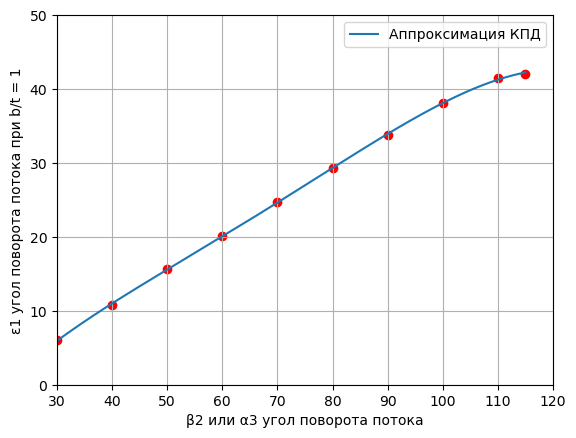

In [689]:
# График с учебника рис. 4

# Точки
β_2_dots = np.array([30, 40, 50, 60, 70, 80, 90, 100, 110, 115])       # точки по оси X для теоретического напора
ε_b_ε_dots = np.array([6, 10.85, 15.65, 20.1, 24.71, 29.31, 33.8, 38.1, 41.5, 42.1])      # точки по оси Y для теоретического напора

# аппроксимация полиномом степени stepen
stepen = 4
coeffs = np.polyfit(β_2_dots, ε_b_ε_dots, stepen)
poly = np.poly1d(coeffs)

smoothness = 100000     # Число точек

β_2_dots_smooth = np.linspace(min(β_2_dots), max(β_2_dots), smoothness)
ε_b_ε_dots_smooth = poly(β_2_dots_smooth)

plt.plot(β_2_dots_smooth, ε_b_ε_dots_smooth, label="Аппроксимация КПД")
plt.scatter(β_2_dots, ε_b_ε_dots, color="red")
plt.xlim(30,120)
plt.ylim(0, 50)
plt.xticks(np.arange(30, 130, 10))  # Установка делений по оси X с шагом 10
plt.yticks(np.arange(0, 60, 10))  # Установка делений по оси Y с шагом 10
plt.xlabel("β2 или α3 угол поворота потока")
plt.ylabel("ε1 угол поворота потока при b/t = 1")
plt.grid(True) # Добавление сетки
plt.legend()
plt.show()

ε_1_x_line = β_2_dots_smooth
ε_1_y_line = ε_b_ε_dots_smooth

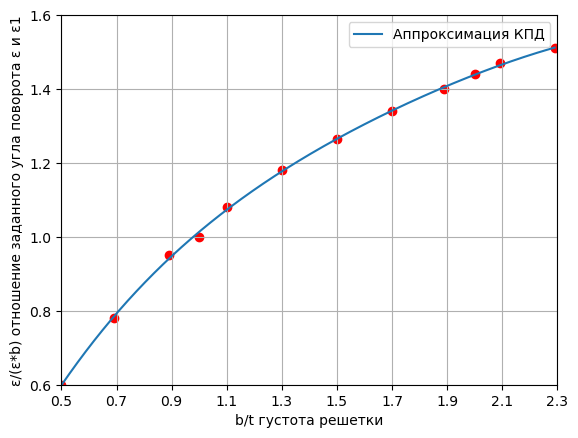

In [690]:
# График с учебника рис. 4

# Точки
b_t_dots = np.array([0.5, 0.69, 0.89, 1.0, 1.1, 1.3, 1.5, 1.7, 1.89, 2.0, 2.09, 2.29])       # точки по оси X для теоретического напора
ε__b_ε_dots = np.array([0.6, 0.78, 0.95, 1.0, 1.08, 1.18, 1.265, 1.34, 1.4, 1.44, 1.47, 1.51])      # точки по оси Y для теоретического напора

#b_t_dots = np.array([0.5, 1.0, 1.5,2.0, 2.29])       # точки по оси X для теоретического напора
#ε__b_ε_dots = np.array([0.6, 1.0, 1.265, 1.44, 1.51])      # точки по оси Y для теоретического напора


# аппроксимация полиномом степени stepen
stepen = 4
coeffs1 = np.polyfit(b_t_dots, ε__b_ε_dots, stepen)
poly1 = np.poly1d(coeffs1)

smoothness = 100000     # Число точек

b_t_dots_smooth = np.linspace(min(b_t_dots), max(b_t_dots), smoothness)
ε__b_ε_dots_smooth = poly1(b_t_dots_smooth)

plt.plot(b_t_dots_smooth, ε__b_ε_dots_smooth, label="Аппроксимация КПД")
plt.scatter(b_t_dots, ε__b_ε_dots, color="red")
plt.xlim(0.5,2.3)
plt.ylim(0.6, 1.6)
plt.xticks(np.arange(0.5, 2.4, 0.2))  # Установка делений по оси X с шагом 0.2
plt.yticks(np.arange(0.6, 1.7, 0.2))  # Установка делений по оси Y с шагом 0.2
plt.xlabel("b/t густота решетки")
plt.ylabel("ε/(ε*b) отношение заданного угла поворота ε и ε1")
plt.grid(True) # Добавление сетки
plt.legend()
plt.show()

ε_отн_x_line = b_t_dots_smooth
ε_отн_y_line = ε__b_ε_dots_smooth

In [691]:
β_1_i = np.degrees(β_1_i)
β_2_i = np.degrees(β_2_i)
α_2_i = np.degrees(α_2_i)
α_3_i = np.degrees(α_3_i)
ε_рк_i = np.degrees(ε_рк_i)
ε_на_i = np.degrees(ε_на_i)
ε_к_рк_i = np.degrees(ε_к_рк_i)
ε_к_на_i = np.degrees(ε_к_на_i)
ε_вт_рк_i = np.degrees(ε_вт_рк_i)
ε_вт_на_i = np.degrees(ε_вт_на_i)

In [692]:
# 1.
# Рабочее колесо
ε_РК_x, ε_РК_i= find_nearest(β_2_i, ε_1_x_line, ε_1_y_line)
bt_1_x, bt_1ср_i= find_nearest((ε_рк_i / ε_РК_i), ε_отн_x_line, ε_отн_y_line)

# Направляющий аппарат
ε_НА_x, ε_НА_i= find_nearest(α_3_i, ε_1_x_line, ε_1_y_line)
bt_2_x, bt_2ср_i= find_nearest((ε_на_i / ε_НА_i), ε_отн_x_line, ε_отн_y_line)

In [693]:
# Углы атаки
i_рк_i = (2.5 * (bt_1ср_i - 1))  # Угол атаки для РК. Тут умножается на deg
i_на_i = (2.5 * (bt_2ср_i - 2))  # Угол атаки для РК

# Коэффициент учитывающий форму средней линии дуги профиля
X_f_отн = 0.5   #  Может быть 0.45 для параболической формы
m_рк_i = 0.23 * (2 * X_f_отн)**2 + 0.18 - 0.002 * β_2_i # Тут делится на deg
m_на_i = 0.23 * (2 * X_f_отн)**2 + 0.18 - 0.002 * α_3_i

θ_рк_i = (np.radians(ε_рк_i - i_рк_i) / (1 - m_рк_i * np.sqrt(1 / bt_1ср_i)))
θ_на_i = (np.radians(ε_на_i - i_на_i) / (1 - m_на_i * np.sqrt(1 / bt_2ср_i)))

if X_f_отн == 0.5:      # Дуга окружности
    χ_рк_i = 0.5 * θ_рк_i
    χ_на_i = 0.5 * θ_на_i
elif X_f_отн == 0.45:   # Параболическая средняя линия
    χ_рк_i = 0.6 * θ_рк_i
    χ_на_i = 0.6 * θ_на_i

v_рк_i = χ_рк_i + β_1_i + i_рк_i
v_на_i = χ_на_i + α_2_i + i_на_i

In [694]:
# Алгоритм подбора параметров для уникальности Z_рк_i и Z_на_i

# Диапазоны параметров для перебора
bt_1к_range = np.arange(1.05, 1.30, 0.01)  # bt_1к_i_отн_нужн от 1.05 до 1.30
bt_2к_range = np.arange(1.05, 1.30, 0.01)  # bt_2к_i_отн_нужн от 1.05 до 1.30
h_рк_start_range = np.arange(2.0, 4.0, 0.1)  # начальное значение h_рк_i_отн
h_на_start_range = np.arange(2.0, 4.0, 0.1)  # начальное значение h_на_i_отн

found = False
for bt_1к_i_отн_нужн in bt_1к_range:
    for bt_2к_i_отн_нужн in bt_2к_range:
        for h_рк_start in h_рк_start_range:
            for h_на_start in h_на_start_range:
                # Задаём удлинение лопаток
                h_рк_i_отн = h_рк_start + (-0.1) * np.arange(N_stupeney)
                h_на_i_отн = h_на_start + (-0.1) * np.arange(N_stupeney)
                
                # Хорды лопаток
                b_рк_i_test = h_рк_i / h_рк_i_отн
                b_на_i_test = h_на_i / h_на_i_отн
                
                # Число лопаток из условия на периферии
                Z_рк_i_test = np.ceil(np.pi * D_к1_i / b_рк_i_test * bt_1к_i_отн_нужн).astype(int)
                Z_рк_i_test[Z_рк_i_test % 2 == 0] += 1  # Делаем нечётными
                
                Z_на_i_test = np.ceil(np.pi * D_к2_i / b_на_i_test * bt_2к_i_отн_нужн).astype(int)
                Z_на_i_test[Z_на_i_test % 2 != 0] += 1  # Делаем чётными
                
                # Проверяем уникальность
                if (len(np.unique(Z_рк_i_test)) == N_stupeney) and (len(np.unique(Z_на_i_test)) == N_stupeney):
                    bt_1к_i_отн_нужн = bt_1к_i_отн_нужн
                    bt_2к_i_отн_нужн = bt_2к_i_отн_нужн
                    h_рк_i_отн = h_рк_i_отн
                    h_на_i_отн = h_на_i_отн
                    b_рк_i = b_рк_i_test
                    b_на_i = b_на_i_test
                    Z_рк_i = Z_рк_i_test
                    Z_на_i = Z_на_i_test
                    found = True
                    print("Параметры подобраны!")
                    print(f"bt_1к_i_отн_нужн = {bt_1к_i_отн_нужн:.3f}")
                    print(f"bt_2к_i_отн_нужн = {bt_2к_i_отн_нужн:.3f}")
                    print(f"h_рк_i_отн[0] = {h_рк_i_отн[0]:.2f}")
                    print(f"h_на_i_отн[0] = {h_на_i_отн[0]:.2f}")
                    break
            if found:
                break
        if found:
            break
    if found:
        break

if not found:
    raise ValueError("Не удалось подобрать параметры для уникальных Z")

print(f"\nZ_рк_i = {Z_рк_i}")
print(f"Уникальных Z_рк_i: {len(np.unique(Z_рк_i))}")
print(f"\nZ_на_i = {Z_на_i}")
print(f"Уникальных Z_на_i: {len(np.unique(Z_на_i))}")

R_сл_рк_i = b_рк_i / (2 * np.sin(np.radians(θ_рк_i) / 2))
R_сл_на_i = b_на_i / (2 * np.sin(np.radians(θ_на_i) / 2))

t_ср_рк_i = b_рк_i / bt_1ср_i
t_ср_на_i = b_на_i / bt_2ср_i

Параметры подобраны!
bt_1к_i_отн_нужн = 1.050
bt_2к_i_отн_нужн = 1.050
h_рк_i_отн[0] = 3.00
h_на_i_отн[0] = 2.20

Z_рк_i = [ 29  31  33  35  37  41  45  49  57  71  93 141]
Уникальных Z_рк_i: 12

Z_на_i = [26 38 42 44 46 48 50 54 58 62 70 84]
Уникальных Z_на_i: 12


In [695]:
# Корректируем значения шага и густоты решетки всязи с увеличением числа лопаток

t_ср_рк_i = np.pi * D_к_i * r_ср2_отн_i / Z_рк_i
bt_1ср_i = b_рк_i / t_ср_рк_i

t_ср_на_i = np.pi * D_к_i * r_ср2_отн_i / Z_на_i
bt_2ср_i = b_на_i / t_ср_на_i

i_рк_i = (2.5 * (bt_1ср_i - 1))  # Угол атаки для РК
i_на_i = (2.5 * (bt_2ср_i - 2))  # Угол атаки для НА

θ_рк_i = (np.radians(ε_рк_i - i_рк_i) / (1 - m_рк_i * np.sqrt(1 / bt_1ср_i)))
θ_на_i = (np.radians(ε_на_i - i_на_i) / (1 - m_на_i * np.sqrt(1 / bt_2ср_i)))

if X_f_отн == 0.5:      # Дуга окружности
    χ_рк_i = 0.5 * θ_рк_i
    χ_на_i = 0.5 * θ_на_i
elif X_f_отн == 0.45:   # Параболическая средняя линия
    χ_рк_i = 0.6 * θ_рк_i
    χ_на_i = 0.6 * θ_на_i

v_рк_i = χ_рк_i + β_1_i + i_рк_i
v_на_i = χ_на_i + α_2_i + i_на_i

R_сл_рк_i = b_рк_i / (2 * np.sin(np.radians(θ_рк_i) / 2))
R_сл_на_i = b_на_i / (2 * np.sin(np.radians(θ_на_i) / 2))

In [696]:
# Периферийный радиус
t_к_рк_i = np.pi * D_к1_i / Z_рк_i
t_к_на_i = np.pi * D_к2_i / Z_на_i

bt_1к_i_отн = b_рк_i / t_к_рк_i
bt_2к_i_отн = b_на_i / t_к_на_i

i_рк_к_i = (2.5 * (bt_1к_i_отн - 1))  # Угол атаки для РК
i_на_к_i = (2.5 * (bt_2к_i_отн - 2))  # Угол атаки для НА

m_рк_к_i = 0.23 * (2 * X_f_отн)**2 + 0.18 - 0.002 * np.degrees(β_2_к_i)
m_на_к_i = 0.23 * (2 * X_f_отн)**2 + 0.18 - 0.002 * np.degrees(α_3_к_i)

θ_рк_к_i = (np.radians(ε_к_рк_i- i_рк_к_i) / (1 - m_рк_к_i * np.sqrt(1 / bt_1к_i_отн)))
θ_на_к_i = (np.radians(ε_к_на_i - i_на_к_i) / (1 - m_на_к_i * np.sqrt(1 / bt_2к_i_отн)))

δ_рк_к_i = m_рк_к_i * θ_рк_к_i * np.sqrt(b_рк_i / t_к_рк_i)
δ_на_к_i = m_на_к_i * θ_на_к_i * np.sqrt(b_на_i / t_к_на_i)

if X_f_отн == 0.5:      # Дуга окружности
    χ_рк_к_i = 0.5 * θ_рк_к_i
    χ_на_к_i = 0.5 * θ_на_к_i
elif X_f_отн == 0.45:   # Параболическая средняя линия
    χ_рк_к_i = 0.6 * θ_рк_к_i
    χ_на_к_i = 0.6 * θ_на_к_i

v_рк_к_i = χ_рк_к_i + np.degrees(β_1_к_i) + i_рк_к_i
v_на_к_i = χ_на_к_i + np.degrees(α_2_к_i) + i_на_к_i

In [697]:
# Втулочный радиус
t_вт_рк_i = np.pi * D_вт1_i / Z_рк_i
t_вт_на_i = np.pi * D_вт2_i / Z_на_i

bt_1вт_i_отн = b_рк_i / t_вт_рк_i
bt_2вт_i_отн = b_на_i / t_вт_на_i

i_рк_вт_i = (2.5 * (bt_1вт_i_отн - 1))  # Угол атаки для РК
i_на_вт_i = (2.5 * (bt_2вт_i_отн - 2))  # Угол атаки для НА

m_рк_вт_i = 0.23 * (2 * X_f_отн)**2 + 0.18 - 0.002 * np.degrees(β_2_вт_i)
m_на_вт_i = 0.23 * (2 * X_f_отн)**2 + 0.18 - 0.002 * np.degrees(α_3_вт_i)

θ_рк_вт_i = (np.radians(ε_вт_рк_i - i_рк_вт_i) / (1 - m_рк_вт_i * np.sqrt(1 / bt_1вт_i_отн)))
θ_на_вт_i = (np.radians(ε_вт_на_i - i_на_вт_i) / (1 - m_на_вт_i * np.sqrt(1 / bt_2вт_i_отн)))

δ_рк_вт_i = m_рк_вт_i * θ_рк_вт_i * np.sqrt(b_рк_i / t_вт_рк_i)
δ_на_вт_i = m_на_вт_i * θ_на_вт_i * np.sqrt(b_на_i / t_вт_на_i)

if X_f_отн == 0.5:      # Дуга окружности
    χ_рк_вт_i = 0.5 * θ_рк_вт_i
    χ_на_вт_i = 0.5 * θ_на_вт_i
elif X_f_отн == 0.45:   # Параболическая средняя линия
    χ_рк_вт_i = 0.6 * θ_рк_вт_i
    χ_на_вт_i = 0.6 * θ_на_вт_i

v_рк_вт_i = χ_рк_вт_i + np.degrees(β_1_вт_i) + i_рк_вт_i
v_на_вт_i = χ_на_вт_i + np.degrees(α_2_вт_i) + i_на_вт_i

R_сл_рк_вт_i = b_рк_i / (2 * np.sin(np.radians(θ_рк_вт_i) / 2))
R_сл_на_вт_i = b_на_i / (2 * np.sin(np.radians(θ_на_вт_i) / 2))

In [698]:
# Профилирование первой ступени
S_1_i = 0.25 * b_рк_i
S_2_i = 0.25 * b_на_i

S_в_РК_i = b_рк_i * np.sin(np.radians(v_рк_вт_i))   # Ширина РК в меридиональной плоскости
S_в_НА_i = b_на_i * np.sin(np.radians(v_на_вт_i))   # Ширина НА в меридиональной плоскости

S_ср_РК_i = b_рк_i * np.sin(np.radians(v_рк_i))     # Ширина РК в средней плоскости
S_ср_НА_i = b_на_i * np.sin(np.radians(v_на_i))     # Ширина НА в средней плоскости

S_к_РК_i = b_рк_i * np.sin(np.radians(v_рк_к_i))    # Ширина РК в средней плоскости
S_к_НА_i = b_на_i * np.sin(np.radians(v_на_к_i))    # Ширина НА в средней плоскости

# Профилирование лопаток

In [699]:
def coordinates_to_file(x_coord_list, y_coord_list, name, folder):
    x_coord_list = list(x_coord_list * 10**3)
    y_coord_list = list(y_coord_list * 10**3)
    # Формируем полный путь к директории
    base_path = os.path.join('Dots_results', folder)
    os.makedirs(base_path, exist_ok=True)
    
    # Объединяем base_path и имя файла
    file_path = os.path.join(base_path, f"{name}.txt")
    
    with open(file_path, 'w', encoding='utf-8') as f:
        for x, y in zip(x_coord_list, y_coord_list):
            f.write(f"{x}\t{y}\n")


In [700]:
# Среднее сечение
# Исходный профиль А-40

x_b_A40 = np.array([1, 1.5, 2.5, 5, 7.5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 70, 80, 90, 95, 100]) * 10**(-2)
y_b_A40 = np.array([1.14, 1.43, 1.85, 2.55, 3.09, 3.525, 4.16, 4.55, 4.788, 4.927, 4.936, 5, 4.858, 4.442, 3.783, 2.85, 1.722, 1.003, 0]) * 10**(-2)

def matrix_gen(len_A_40, len_θ):
    for _ in range(len_θ):
        yield [0] * len_A_40

def np_cot(num):
    return (1/np.tan(num))

def np_acot(num):
    return (1 / np.atan(num))

In [701]:
def dots_creating_form(x_b_A40, y_b_A40, θ_рк_i, θ_на_i, b_рк_i, b_на_i, c_a1_i, c_a2_i, c_a3_i, β_1_i, β_2_i, α_3_i, α_2_i, bt_1ср_i, bt_2ср_i):
    # Среднее сечение
    # Относительные координаты точек средней линии лопаток
    y_b_СР_сл_РК_i = list(matrix_gen((len(y_b_A40)), (len(θ_рк_i))))    # Создание пустого списка
    for i, θ_рк_num in enumerate(θ_рк_i):
        y_b_СР_сл_РК_i[i] = np.sqrt(1/4 * (np_cot(θ_рк_num / 2))**2 + x_b_A40 * (1 - x_b_A40)) - 1/2 * (np_cot(θ_рк_num / 2))
    y_b_СР_сл_РК_i = np.array(y_b_СР_сл_РК_i)

    y_b_СР_сл_НА_i = list(matrix_gen((len(y_b_A40)), (len(θ_на_i))))    # Создание пустого списка
    for i, θ_на_num in enumerate(θ_на_i):
        y_b_СР_сл_НА_i[i] = np.sqrt(1/4 * (np_cot(θ_на_num / 2))**2 + x_b_A40 * (1 - x_b_A40)) - 1/2 * (np_cot(θ_на_num / 2))
    y_b_СР_сл_НА_i = np.array(y_b_СР_сл_НА_i)

    # Относительные координаты спинки лопаток
    y_b_СР_с_РК_i = y_b_СР_сл_РК_i + y_b_A40
    y_b_СР_с_НА_i = y_b_СР_сл_НА_i + y_b_A40

    # Относительные координаты корытца лопаток
    y_b_СР_к_РК_i = y_b_СР_сл_РК_i - y_b_A40
    y_b_СР_к_НА_i = y_b_СР_сл_НА_i - y_b_A40

    # Абсолютные координаты
    x_РК_ср_i = list(matrix_gen((len(x_b_A40)), (len(b_рк_i))))    # Создание пустого списка
    for i, b_рк_num in enumerate(b_рк_i):
        x_РК_ср_i[i] = x_b_A40 * b_рк_num
    x_РК_ср_i = np.array(x_РК_ср_i)
    y_РК_ср_i = np.zeros(len(x_b_A40))

    x_НА_ср_i = list(matrix_gen(len(x_b_A40), len(b_на_i)))
    for i, b_на_num in enumerate(b_на_i):
        x_НА_ср_i[i] = x_b_A40 * b_на_num
    x_НА_ср_i = np.array(x_НА_ср_i)
    y_НА_ср_i = np.zeros(len(x_b_A40))

    y_с_РК_ср_i = list(matrix_gen(len(x_b_A40), len(b_рк_i)))
    for i, b_рк_num in enumerate(b_рк_i):
        y_с_РК_ср_i[i] = y_b_СР_с_РК_i[i] * b_рк_num
    y_с_РК_ср_i = np.array(y_с_РК_ср_i)

    y_с_НА_ср_i = list(matrix_gen(len(x_b_A40), len(b_на_i)))
    for i, b_на_num in enumerate(b_на_i):
        y_с_НА_ср_i[i] = y_b_СР_с_НА_i[i] * b_на_num
    y_с_НА_ср_i = np.array(y_с_НА_ср_i)

    y_к_РК_ср_i = list(matrix_gen(len(x_b_A40), len(b_рк_i)))
    for i, b_рк_num in enumerate(b_рк_i):
        y_к_РК_ср_i[i] = y_b_СР_к_РК_i[i] * b_рк_num
    y_к_РК_ср_i = np.array(y_к_РК_ср_i)

    y_к_НА_ср_i = list(matrix_gen(len(x_b_A40), len(b_на_i)))
    for i, b_на_num in enumerate(b_на_i):
        y_к_НА_ср_i[i] = y_b_СР_к_НА_i[i] * b_на_num
    y_к_НА_ср_i = np.array(y_к_НА_ср_i)

    i = 1   # Что-то странное у меня с θ_рк_i по сечениям. по идее к периферии угол должен увеличиваться, поэтому тут 1, если исправлю, то будет 0
    j = 0   

    X_РК_цм = np.sum(x_РК_ср_i[i]) / len(x_РК_ср_i[i])
    Y_РК_цм = (np.sum(y_с_РК_ср_i[i]) + np.sum(y_к_РК_ср_i[i])) / (len(y_с_РК_ср_i[i]) + len(y_к_РК_ср_i[i]))
    X_НА_цм = np.sum(x_НА_ср_i[j]) / len(x_НА_ср_i[j])
    Y_НА_цм = (np.sum(y_с_НА_ср_i[j]) + np.sum(y_к_НА_ср_i[j])) / (len(y_с_НА_ср_i[j]) + len(y_к_НА_ср_i[j]))

    X_ср_РК_сп_i = (x_РК_ср_i[i] - X_РК_цм) * np.cos(θ_рк_i[i]) - (y_с_РК_ср_i[i] - Y_РК_цм) * np.sin(θ_рк_i[i])
    Y_ср_РК_сп_i = (x_РК_ср_i[i] - X_РК_цм) * np.sin(θ_рк_i[i]) + (y_с_РК_ср_i[i] - Y_РК_цм) * np.cos(θ_рк_i[i])
    X_ср_НА_сп_i = (x_НА_ср_i[j] - X_НА_цм) * np.cos(θ_на_i[j]) - (y_с_НА_ср_i[j] - Y_НА_цм) * np.sin(θ_на_i[j])
    Y_ср_НА_сп_i = (x_НА_ср_i[j] - X_НА_цм) * np.sin(θ_на_i[j]) + (y_с_НА_ср_i[j] - Y_НА_цм) * np.cos(θ_на_i[j])

    X_ср_РК_к_i = (x_РК_ср_i[i] - X_РК_цм) * np.cos(θ_рк_i[i]) - (y_к_РК_ср_i[i] - Y_РК_цм) * np.sin(θ_рк_i[i])
    Y_ср_РК_к_i = (x_РК_ср_i[i] - X_РК_цм) * np.sin(θ_рк_i[i]) + (y_к_РК_ср_i[i] - Y_РК_цм) * np.cos(θ_рк_i[i])
    X_ср_НА_к_i = (x_НА_ср_i[j] - X_НА_цм) * np.cos(θ_на_i[j]) - (y_к_НА_ср_i[j] - Y_НА_цм) * np.sin(θ_на_i[j])
    Y_ср_НА_к_i = (x_НА_ср_i[j] - X_НА_цм) * np.sin(θ_на_i[j]) + (y_к_НА_ср_i[j] - Y_НА_цм) * np.cos(θ_на_i[j])

    # Диффузность решетки РК:
    β_ср_РК1_i = (np_acot(((np_cot(np.radians(β_1_i))) + (np_cot(np.radians(β_2_i)))) / 2))
    D_L_РК1_i = 1 - (c_a2_i / c_a1_i) * (np.sin(np.radians(β_1_i))) / (np.sin(np.radians(β_2_i))) + (((np_cot(np.radians(β_1_i))) - (c_a2_i / c_a1_i) * (np_cot(np.radians(β_2_i)))) / (2 * bt_1ср_i)) * np.sin(np.radians(β_1_i))

    # Диффузность решетки НА:
    α_ср_НА1_i = (np_acot(((np_cot(np.radians(α_2_i))) + (np_cot(np.radians(α_3_i)))) / 2))
    D_L_НА1_i = 1 - (c_a3_i / c_a2_i) * (np.sin(np.radians(α_2_i))) / (np.sin(np.radians(α_3_i))) + (((np_cot(np.radians(α_2_i))) - (c_a3_i / c_a2_i) * (np_cot(np.radians(α_3_i)))) / (2 * bt_2ср_i)) * np.sin(np.radians(α_2_i))

    return(X_ср_РК_сп_i, Y_ср_РК_сп_i, X_ср_РК_к_i, Y_ср_РК_к_i, X_ср_НА_сп_i, Y_ср_НА_сп_i, X_ср_НА_к_i, Y_ср_НА_к_i)

In [702]:
np.degrees(θ_рк_вт_i), np.degrees(θ_рк_i), np.degrees(θ_рк_к_i)

(array([ 9.67522212, -6.49641917, -3.77136214,  0.75706219,  5.59515295,
        10.01430087, 14.31486901, 18.50665249, 22.07575603, 25.0994368 ,
        28.02760587, 30.75190914]),
 array([25.37452678, 16.99061417, 16.88824098, 17.96914008, 19.51200974,
        20.93073128, 22.61556423, 24.58279997, 26.23425622, 27.63389338,
        29.22814662, 30.84782625]),
 array([13.15595676, 13.88012465, 14.7013212 , 15.63968805, 16.72097487,
        17.58025494, 18.69586659, 20.1274493 , 21.33754988, 22.42707227,
        23.84751126, 25.46585591]))

In [703]:
np.degrees(θ_на_вт_i), np.degrees(θ_на_i), np.degrees(θ_на_к_i)

(array([21.96093382, 27.62936286, 29.55972084, 31.12972912, 32.33382734,
        33.26747411, 33.94934252, 33.99819289, 33.82737858, 33.46990016,
        32.39565598, 31.01380984]),
 array([28.28972339, 19.22161088, 19.04425793, 20.2915147 , 21.93523046,
        23.79068096, 25.78368016, 27.53038158, 29.39307166, 31.39813188,
        32.99062796, 34.19962259]),
 array([30.12016602, 31.82985446, 33.14706801, 34.37687042, 35.30324967,
        35.97460354, 36.39480447, 36.15723745, 35.69971096, 35.05781193,
        33.6782621 , 31.9888828 ]))

In [704]:
# Среднее сечение
X_ср_РК_сп_i, Y_ср_РК_сп_i, X_ср_РК_к_i, Y_ср_РК_к_i, X_ср_НА_сп_i, Y_ср_НА_сп_i, X_ср_НА_к_i, Y_ср_НА_к_i = dots_creating_form(x_b_A40, y_b_A40, θ_рк_i, θ_на_i, b_рк_i, b_на_i, c_a1_i, c_a2_i, c_a3_i, β_1_i, β_2_i, α_3_i, α_2_i, bt_1ср_i, bt_2ср_i)
coordinates_to_file(X_ср_РК_сп_i, Y_ср_РК_сп_i, 'РК Спинка', 'Среднее сечение')
coordinates_to_file(X_ср_РК_к_i, Y_ср_РК_к_i, 'РК Корыто', 'Среднее сечение')
coordinates_to_file(X_ср_НА_сп_i, Y_ср_НА_сп_i, 'НА Спинка', 'Среднее сечение')
coordinates_to_file(X_ср_НА_к_i, Y_ср_НА_к_i, 'НА Корыто', 'Среднее сечение')

# Втулочное сечение
x_РК_ВТ_i, y_с_РК_ВТ_i, x_РК_ВТ_i, y_к_РК_ВТ_i, x_НА_ВТ_i, y_с_НА_ВТ_i, x_НА_ВТ_i,y_к_НА_ВТ_i = dots_creating_form(x_b_A40, y_b_A40, θ_рк_вт_i, θ_на_вт_i, b_рк_i, b_на_i, c_a1_i, c_a2_i, c_a3_i, β_1_i, β_2_i, α_3_i, α_2_i, bt_1вт_i_отн, bt_2вт_i_отн)
coordinates_to_file(x_РК_ВТ_i, y_с_РК_ВТ_i, 'РК Спинка', 'Втулочное сечение')
coordinates_to_file(x_РК_ВТ_i, y_к_РК_ВТ_i, 'РК Корыто', 'Втулочное сечение')
coordinates_to_file(x_НА_ВТ_i, y_с_НА_ВТ_i, 'НА Спинка', 'Втулочное сечение')
coordinates_to_file(x_НА_ВТ_i, y_к_НА_ВТ_i, 'НА Корыто', 'Втулочное сечение')

#Периферийное сечение
x_РК_К_i, y_с_РК_К_i, x_РК_К_i, y_к_РК_К_i, x_НА_К_i, y_с_НА_К_i, x_НА_К_i,y_к_НА_К_i = dots_creating_form(x_b_A40, y_b_A40, θ_рк_к_i, θ_на_к_i, b_рк_i, b_на_i, c_a1_i, c_a2_i, c_a3_i, β_1_i, β_2_i, α_3_i, α_2_i, bt_1к_i_отн, bt_2к_i_отн)
coordinates_to_file(x_РК_К_i, y_с_РК_К_i, 'РК Спинка', 'Периферийное сечение')
coordinates_to_file(x_РК_К_i, y_к_РК_К_i, 'РК Корыто', 'Периферийное сечение')
coordinates_to_file(x_НА_К_i, y_с_НА_К_i, 'НА Спинка', 'Периферийное сечение')
coordinates_to_file(x_НА_К_i, y_к_НА_К_i, 'НА Корыто', 'Периферийное сечение')

In [705]:
import numpy as np
import pandas as pd
import os



# ═════════════════════════════════════════════════════════════════════════
# СПИСОК ПЕРЕМЕННЫХ (твой)
# ═════════════════════════════════════════════════════════════════════════

list_names = [
    "ε_РК_x","ε_РК_i","bt_1_x","bt_1ср_i",
    "ε_НА_x","ε_НА_i","bt_2_x","bt_2ср_i",
    "i_рк_i","i_на_i",
    "X_f_отн","m_рк_i","m_на_i",
    "θ_рк_i","θ_на_i","χ_рк_i","χ_на_i",
    "v_рк_i","v_на_i",
    "h_рк_i_отн","h_на_i_отн",
    "b_рк_i","b_на_i",
    "R_сл_рк_i","R_сл_на_i",
    "t_ср_рк_i","t_ср_на_i",
    "Z_рк_i","Z_на_i",
    "t_к_рк_i","t_к_на_i",
    "bt_1к_i_отн","bt_2к_i_отн",
    "i_рк_к_i","i_на_к_i",
    "m_рк_к_i","m_на_к_i",
    "θ_рк_к_i","θ_на_к_i",
    "δ_рк_к_i","δ_на_к_i",
    "χ_рк_к_i","χ_на_к_i",
    "v_рк_к_i","v_на_к_i",
    "t_вт_рк_i","t_вт_на_i",
    "bt_1вт_i_отн","bt_2вт_i_отн",
    "i_рк_вт_i","i_на_вт_i",
    "m_рк_вт_i","m_на_вт_i",
    "θ_рк_вт_i","θ_на_вт_i",
    "δ_рк_вт_i","δ_на_вт_i",
    "χ_рк_вт_i","χ_на_вт_i",
    "v_рк_вт_i","v_на_вт_i",
    "R_сл_рк_вт_i","R_сл_на_вт_i",
    "S_1_i","S_2_i",
    "S_в_РК_i","S_в_НА_i",
    "S_ср_РК_i","S_ср_НА_i",
    "S_к_РК_i","S_к_НА_i",
    "y_b_СР_сл_РК_i","y_b_СР_сл_НА_i",
    "y_b_СР_с_РК_i","y_b_СР_с_НА_i",
    "y_b_СР_к_РК_i","y_b_СР_к_НА_i",
    "x_РК_ср_i","x_НА_ср_i",
    "y_с_РК_ср_i","y_с_НА_ср_i",
    "y_к_РК_ср_i","y_к_НА_ср_i",
    "β_ср_РК1_i","D_L_РК1_i",
    "α_ср_НА1_i","D_L_НА1_i",
    "y_b_ВТ_сл_РК_i","y_b_ВТ_сл_НА_i",
    "y_b_ВТ_с_РК_i","y_b_ВТ_с_НА_i",
    "y_b_ВТ_к_РК_i","y_b_ВТ_к_НА_i",
    "x_РК_ВТ_i","x_НА_ВТ_i",
    "y_с_РК_ВТ_i","y_с_НА_ВТ_i",
    "y_к_РК_ВТ_i","y_к_НА_ВТ_i",
    "β_ВТ_РК1_i","D_L_ВТ_РК1_i",
    "α_ВТ_НА1_i","D_L_ВТ_НА1_i",
    "y_b_К_сл_РК_i","y_b_К_сл_НА_i",
    "y_b_К_с_РК_i","y_b_К_с_НА_i",
    "y_b_К_к_РК_i","y_b_К_к_НА_i",
    "x_РК_К_i","x_НА_К_i",
    "y_с_РК_К_i","y_с_НА_К_i",
    "y_к_РК_К_i","y_к_НА_К_i",
    "β_К_РК1_i","D_L_К_РК1_i",
    "α_К_НА1_i","D_L_К_НА1_i"
]

# ═════════════════════════════════════════════════════════════════════════
# СБОР ДАННЫХ
# ═════════════════════════════════════════════════════════════════════════

data_1d = {}     # для общего листа
data_2d = {}     # для отдельных листов

for name in list_names:
    val = globals().get(name, None)

    if val is None:
        continue

    # ───────────── numpy массив
    if isinstance(val, np.ndarray):

        if val.ndim == 1:
            data_1d[name] = val.tolist()

        elif val.ndim == 2:
            data_2d[name] = val  # отдельно

        else:
            data_1d[name] = [str(val)]

    # ───────────── список
    elif isinstance(val, (list, tuple)):
        data_1d[name] = list(val)

    # ───────────── скаляр
    else:
        data_1d[name] = [val]


# ═════════════════════════════════════════════════════════════════════════
# ВЫРАВНИВАНИЕ 1D ДАННЫХ
# ═════════════════════════════════════════════════════════════════════════

if data_1d:
    max_len = max(len(col) for col in data_1d.values())

    for key, col in data_1d.items():
        if len(col) < max_len:
            data_1d[key] = col + [np.nan] * (max_len - len(col))

    df_main = pd.DataFrame(data_1d)
else:
    df_main = pd.DataFrame({"info": ["Нет данных"]})


# ═════════════════════════════════════════════════════════════════════════
# СОХРАНЕНИЕ В EXCEL
# ═════════════════════════════════════════════════════════════════════════
os.makedirs("results", exist_ok=True)
with pd.ExcelWriter("results/Профилирование_лопаток.xlsx", engine="openpyxl") as writer:

    # основной лист
    df_main.to_excel(writer, sheet_name="Профилир_ВСЁ", index=False)

    # отдельные листы для 2D массивов
    for name, arr in data_2d.items():
        try:
            df = pd.DataFrame(arr)
            df.to_excel(writer, sheet_name=name[:31], index=False)
        except Exception as e:
            pd.DataFrame({"error": [str(e)]}) \
                .to_excel(writer, sheet_name=name[:31], index=False)

print("✅ Экспорт завершён")
print("📄 Лист 'ВСЕ_данные' — все 1D данные")
print("📄 2D массивы — отдельные листы")

✅ Экспорт завершён
📄 Лист 'ВСЕ_данные' — все 1D данные
📄 2D массивы — отдельные листы
